# Airbnb in Asheville
Monica Reyes-Lopez\
DSBA 6211 Advanced Business Analytics\
Spring 2026

Data Dictionary
https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596


## Leading questions:
- what factors affect air bnbs listings' performance?
- propose reasonable indicators to quantify an individual listings' performance
    - avg monthly occupancy rate, or avg monthly income per room
- identify suitable independent variables based on available data sources

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora, models
from gensim.parsing.preprocessing import (
    STOPWORDS, preprocess_string,
    strip_tags, strip_punctuation,
    strip_numeric, strip_multiple_whitespaces,
    remove_stopwords, stem_text
)
import warnings
warnings.filterwarnings("ignore")

In [2]:
# bringing in the most recent data 
calendar_recent = pd.read_csv(r'data\now\calendar.csv.gz', compression='gzip')
listings_recent = pd.read_csv(r'data\now\listings.csv.gz', compression='gzip')
reviews_recent = pd.read_csv(r'data\now\reviews.csv.gz', compression='gzip')
neighborhoods_recent = pd.read_csv(r'data\now\neighbourhoods.csv')
neighborhoods_geo = json.load(open(r'data\now\neighbourhoods.geojson', 'r'))
    # neighborhoods_geo is the same in both the archived and recent data, so we only need to load it once
    
# summary data
listing_summary_recent = pd.read_csv(r'data\now\summary\listings.csv')
reviews_summary_recent = pd.read_csv(r'data\now\summary\reviews.csv')
# -----------------------------------------------------------------------------------

# archived data
calendar_archived = pd.read_csv(r'data\archived\calendar.csv.gz', compression='gzip')
listings_archived = pd.read_csv(r'data\archived\listings.csv.gz', compression='gzip')
reviews_archived = pd.read_csv(r'data\archived\reviews.csv.gz', compression='gzip')
neighborhoods_archived = pd.read_csv(r'data\archived\neighbourhoods.csv')
# neighborhoods_geo_archived = json.load(open(r'data\archived\neighbourhoods.geojson', 'r'))

# summary data
listing_summary_archived = pd.read_csv(r'data\archived\summary\listings.csv')
reviews_summary_archived = pd.read_csv(r'data\archived\summary\reviews.csv')

# -----------------------------------------------------------------------------------

# making master df for each dataset
calendar = pd.concat([calendar_recent, calendar_archived], ignore_index=True)
calendar['date'] = pd.to_datetime(calendar['date'])

listings = pd.concat([listings_recent, listings_archived], ignore_index=True)
reviews = pd.concat([reviews_recent, reviews_archived], ignore_index=True)
neighborhoods = neighborhoods_recent.copy()
# neighborhoods_geo and neighborhoods do not need to be concatenated as the data is the same in both files, so we can just use one of them
# summary data
listing_summary = pd.concat([listing_summary_recent, listing_summary_archived], ignore_index=True)
reviews_summary = pd.concat([reviews_summary_recent, reviews_summary_archived], ignore_index=True)


In [3]:
## what is the shape of each dataset?
print("Calendar dataset shape:", calendar_recent.shape)
print("Listings dataset shape:", listings_recent.shape)
print("Reviews dataset shape:", reviews_recent.shape)
print("Neighborhoods dataset shape:", neighborhoods_recent.shape)
print("Neighborhoods GeoJSON keys:", neighborhoods_geo.keys())



Calendar dataset shape: (1040980, 7)
Listings dataset shape: (2852, 79)
Reviews dataset shape: (324317, 6)
Neighborhoods dataset shape: (8, 2)
Neighborhoods GeoJSON keys: dict_keys(['type', 'features'])


### occupancy rate per listing

In [4]:
# sort first so rolling window makes sense chronologically
calendar = calendar.sort_values(["listing_id", "date"])

# ensure available is numeric (t/f -> 1/0)
calendar["available"] = calendar["available"].replace({"t": 1, "f": 0}).astype(float)

# rolling 30-day occupancy rate per listing
calendar["occupancy_30d"] = (
    calendar.groupby("listing_id")["available"]
    .transform(lambda x: x.rolling(30, min_periods=15).mean())
)
# remember: available=1 means OPEN, so booked = 1 - available
calendar["occupancy_30d"] = 1 - calendar["occupancy_30d"]

# if you want a single summary number per listing (for modeling):
occupancy_per_listing = (
    calendar.groupby("listing_id")["available"]
    .apply(lambda x: 1 - x.mean())
    .reset_index()
    .rename(columns={"available": "occupancy_rate"})
)

occupancy_per_listing.describe()
# listings.describe()

,listing_id,occupancy_rate
count,2.852000e+03,2852.000000
mean,4.968465e+17,0.386393
std,5.463762e+17,0.334146
min,1.553050e+05,0.000000
25%,3.352236e+07,0.090411
50%,5.356557e+07,0.279452
75%,1.000807e+18,0.679452
max,1.513870e+18,1.000000


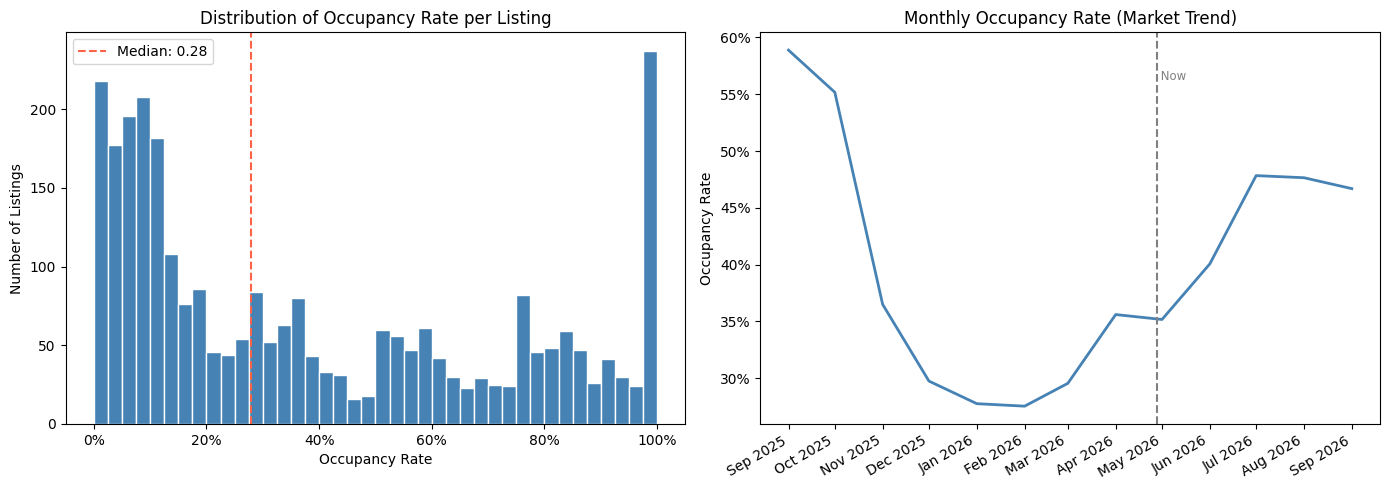

In [5]:
import matplotlib.dates as mdates

# market-level monthly occupancy rate
monthly_occupancy_ts = (
    calendar
    .groupby(calendar['date'].dt.to_period('M'))['available']
    .mean()
    .rename('occupancy_rate')
)
monthly_occupancy_ts = 1 - monthly_occupancy_ts  # available=1 means open, so booked = 1 - available
monthly_occupancy_ts.index = monthly_occupancy_ts.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: distribution of per-listing occupancy rates ---
ax = axes[0]
ax.hist(occupancy_per_listing['occupancy_rate'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(occupancy_per_listing['occupancy_rate'].median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Median: {occupancy_per_listing['occupancy_rate'].median():.2f}")
ax.set_title('Distribution of Occupancy Rate per Listing')
ax.set_xlabel('Occupancy Rate')
ax.set_ylabel('Number of Listings')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()

# --- right: market-level monthly occupancy trend ---
ax = axes[1]
plot_ts = monthly_occupancy_ts[monthly_occupancy_ts.index >= '2025-09-01']
ax.plot(plot_ts.index, plot_ts.values, color='steelblue', linewidth=2)


ax.axvline(pd.Timestamp('2026-04-28'), color='gray', linestyle='--', linewidth=1.5)
ax.text(pd.Timestamp('2026-04-28'), plot_ts.max() * 0.97, ' Now', color='gray', fontsize=8.5, va='top')
ax.set_title('Monthly Occupancy Rate (Market Trend)')
ax.set_xlabel('')
ax.set_ylabel('Occupancy Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig("occupancy_trend.png", dpi=150, bbox_inches="tight")
plt.show()


### revenue proxy

In [6]:
# clean price (stored as string like "$150.00")
listings["price_clean"] = (
    listings["price"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)

# merge price into occupancy table and calculate estimated monthly revenue
revenue_df = occupancy_per_listing.merge(
    listings[["id", "price_clean"]],
    left_on="listing_id",
    right_on="id",
    how="left"
)

revenue_df["monthly_revenue_proxy"] = (
    revenue_df["occupancy_rate"] * revenue_df["price_clean"] * 30
)

revenue_df[["listing_id", "occupancy_rate", "price_clean", "monthly_revenue_proxy"]].describe()

,listing_id,occupancy_rate,price_clean,monthly_revenue_proxy
count,5.538000e+03,5538.000000,4898.000000,4898.000000
mean,4.771123e+17,0.387076,189.055941,1753.650237
std,5.345070e+17,0.334227,329.932592,3421.102143
min,1.553050e+05,0.000000,18.000000,0.000000
25%,3.301826e+07,0.090411,93.000000,347.321918
50%,5.298162e+07,0.279452,131.000000,1002.904110
75%,9.752685e+17,0.679452,208.000000,2161.500000
max,1.513870e+18,1.000000,9999.000000,83827.232877


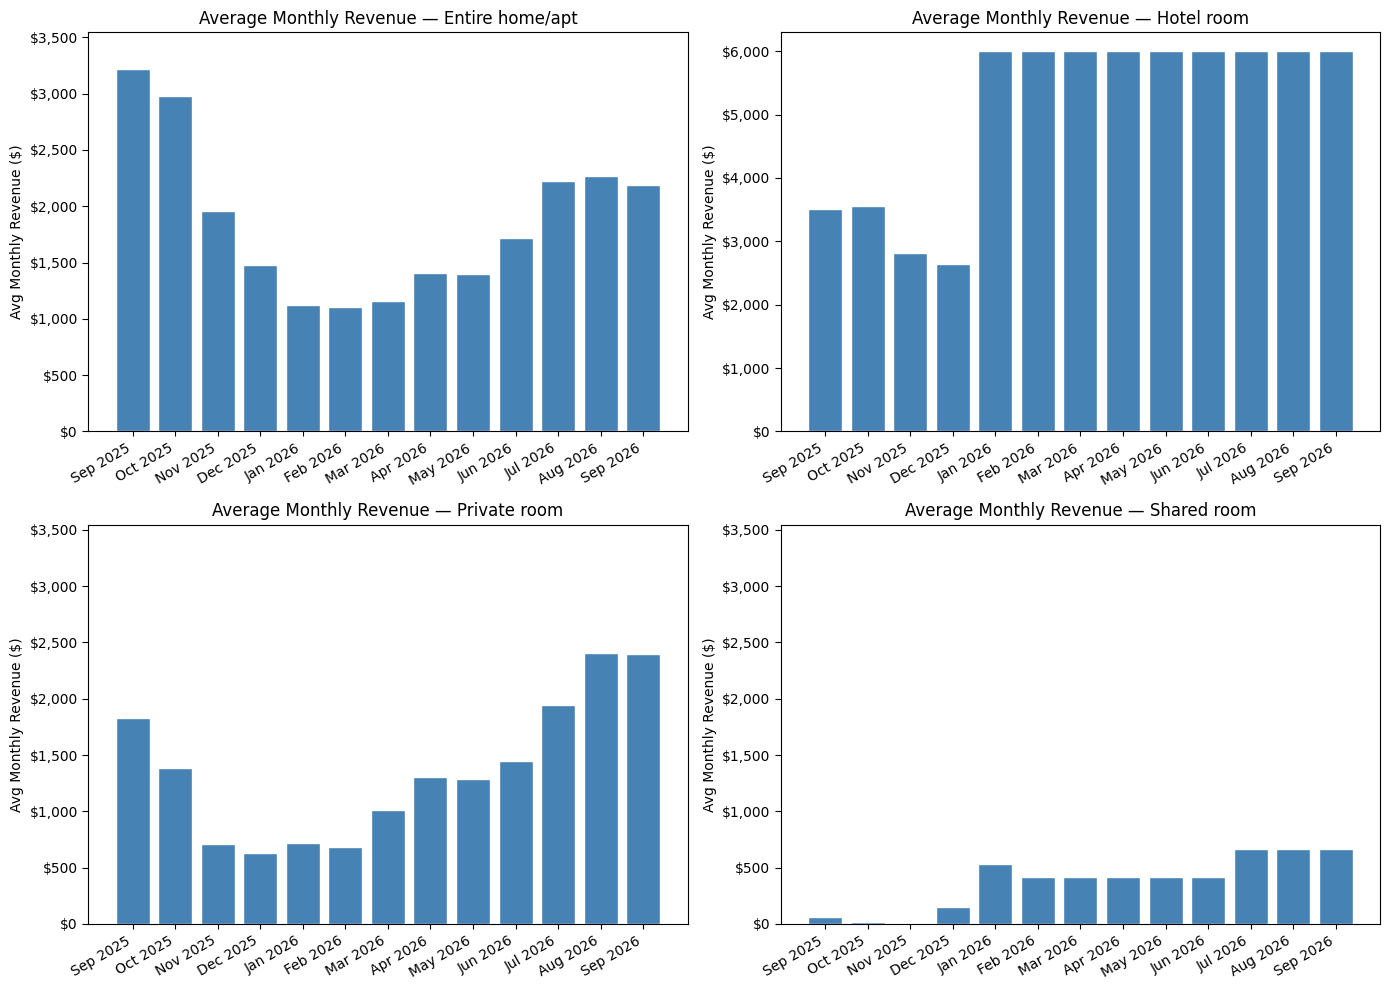

In [7]:
# monthly occupancy rate per listing
monthly_listing_occ = (
    calendar
    .assign(month=calendar["date"].dt.to_period("M"))
    .groupby(["listing_id", "month"])["available"]
    .mean()
    .reset_index()
)
monthly_listing_occ["occupancy_rate"] = 1 - monthly_listing_occ["available"]

# merge price and room_type, then compute monthly revenue
monthly_listing_rev = monthly_listing_occ.merge(
    listings[["id", "price_clean", "room_type"]],
    left_on="listing_id", right_on="id",
    how="left"
)
monthly_listing_rev["monthly_revenue"] = (
    monthly_listing_rev["occupancy_rate"] * monthly_listing_rev["price_clean"] * 30
)
monthly_listing_rev["month"] = monthly_listing_rev["month"].dt.to_timestamp()
monthly_listing_rev = monthly_listing_rev[monthly_listing_rev["month"] >= "2025-09-01"]

avg_rev_by_type_month = (
    monthly_listing_rev
    .groupby(["room_type", "month"])["monthly_revenue"]
    .mean()
    .reset_index()
)

room_types = sorted(avg_rev_by_type_month["room_type"].unique())
y_max = (
    avg_rev_by_type_month[avg_rev_by_type_month["room_type"] != "Hotel room"]["monthly_revenue"].max()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, room_type in zip(axes, room_types):
    data = avg_rev_by_type_month[avg_rev_by_type_month["room_type"] == room_type].sort_values("month")
    ax.bar(data["month"].dt.strftime("%b %Y"), data["monthly_revenue"],
           color="steelblue", edgecolor="white")
    ax.set_title(f"Average Monthly Revenue — {room_type}")
    ax.set_ylabel("Avg Monthly Revenue ($)")
    if room_type != "Hotel room":
        ax.set_ylim(0, y_max * 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.tick_params(axis="y", direction="out", length=4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# hide any unused subplots if fewer than 4 room types
for ax in axes[len(room_types):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("average_monthly_revenue_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()


### review velocity

In [8]:
# make sure date is datetime
reviews['date'] = pd.to_datetime(reviews['date'])

# create a year-month period column
reviews['year_month'] = reviews['date'].dt.to_period('M')

# count reviews per listing per month
review_velocity = (
    reviews.groupby(['listing_id', 'year_month'])
    .size()
    .reset_index(name='reviews_that_month')
)

# average monthly review rate per listing (single summary number)
avg_review_velocity = (
    review_velocity.groupby('listing_id')['reviews_that_month']
    .mean()
    .reset_index()
    .rename(columns={'reviews_that_month': 'avg_monthly_reviews'})
)

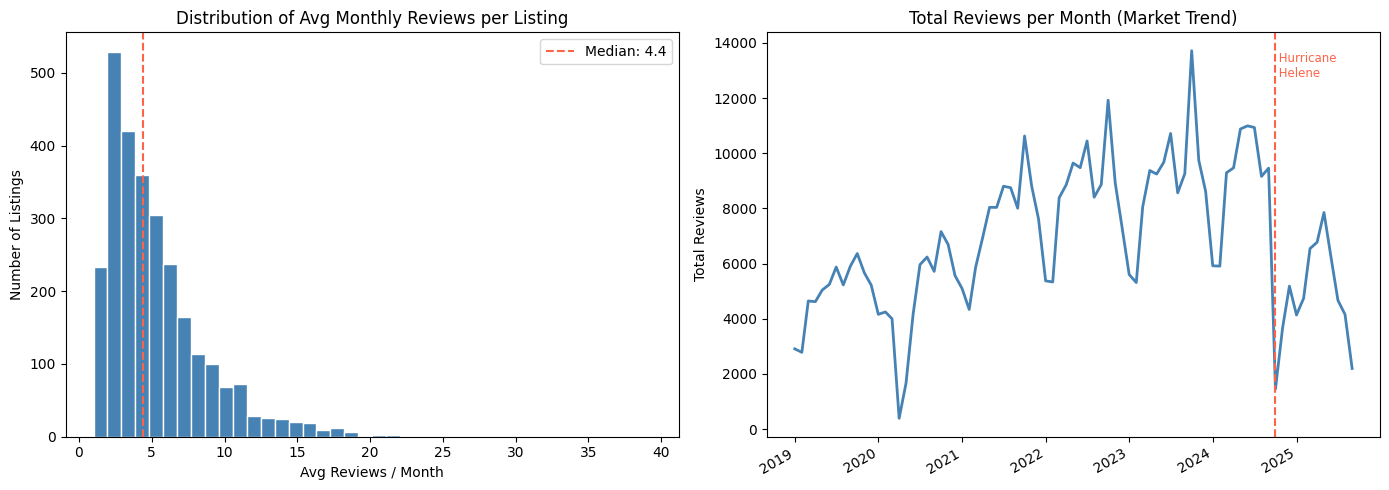

In [9]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: distribution of avg monthly reviews per listing ---
ax = axes[0]
ax.hist(avg_review_velocity['avg_monthly_reviews'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(avg_review_velocity['avg_monthly_reviews'].median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Median: {avg_review_velocity['avg_monthly_reviews'].median():.1f}")
ax.set_title('Distribution of Avg Monthly Reviews per Listing')
ax.set_xlabel('Avg Reviews / Month')
ax.set_ylabel('Number of Listings')
ax.legend()

# --- right: total reviews per month (market-level trend) ---
ax = axes[1]
monthly_review_counts = (
    review_velocity
    .assign(month=review_velocity['year_month'].dt.to_timestamp())
    .groupby('month')['reviews_that_month']
    .sum()
    .reset_index()
)
monthly_review_counts = monthly_review_counts[monthly_review_counts['month'] >= '2019-01-01']
ax.plot(monthly_review_counts['month'], monthly_review_counts['reviews_that_month'],
        color='steelblue', linewidth=2)

helene_date = pd.Timestamp('2024-09-27')
ax.axvline(helene_date, color='tomato', linestyle='--', linewidth=1.5)
ax.text(helene_date, ax.get_ylim()[1] * 0.95, ' Hurricane\n Helene',
        color='tomato', fontsize=8.5, va='top')

ax.set_title('Total Reviews per Month (Market Trend)')
ax.set_xlabel('')
ax.set_ylabel('Total Reviews')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig("monthly_reviews_trend.png", dpi=150, bbox_inches="tight")
plt.show()


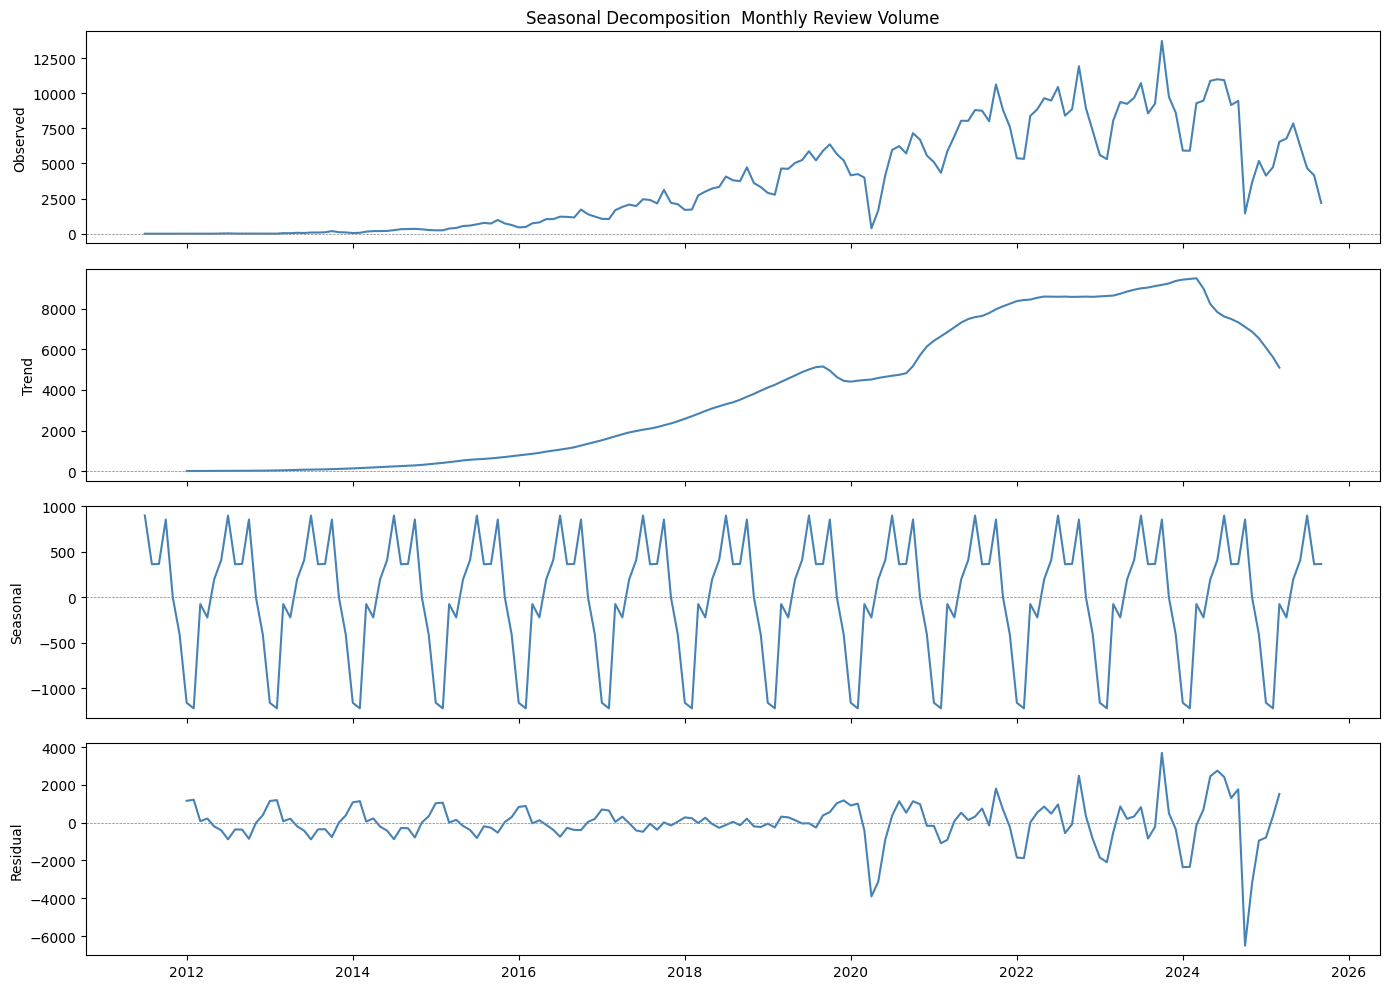

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# build a clean monthly series (full history, no cutoff)
ts = (
    review_velocity
    .assign(month=review_velocity['year_month'].dt.to_timestamp())
    .groupby('month')['reviews_that_month']
    .sum()
    .asfreq('MS')
    .fillna(0)
)

#  1. Seasonal decomposition 
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, component, label in zip(
    axes,
    [ts, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal', 'Residual']
):
    ax.plot(component, color='steelblue', linewidth=1.5)
    ax.set_ylabel(label)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_title('Seasonal Decomposition  Monthly Review Volume')
plt.tight_layout()
plt.savefig("monthly_reviews_seasonal_decomposition.png", dpi=150, bbox_inches="tight") 
plt.show()

 ADF Test: Original series 
  Test statistic : -1.4970
  p-value        : 0.5350
  Stationary    : No --
 ADF Test: First difference (d=1) 
  Test statistic : -2.1007
  p-value        : 0.2442
  Stationary    : No --
 ADF Test: First + seasonal diff (d=1, D=1) 
  Test statistic : -4.6190
  p-value        : 0.0001
  Stationary    : Yes 

 Using d=1, D=1 in SARIMA


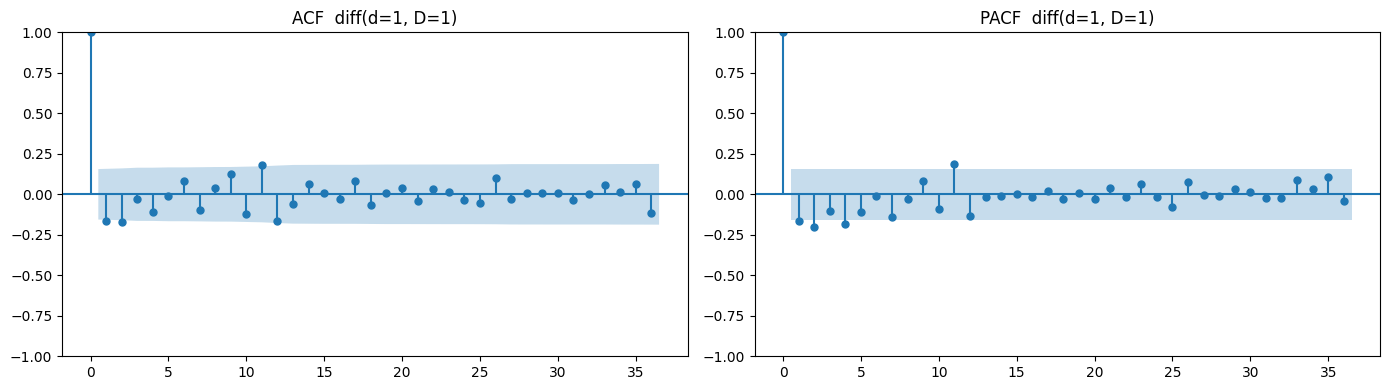

In [11]:

#  2. Stationarity: ADF test 
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f" ADF Test: {label} ")
    print(f"  Test statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Stationary    : {'Yes ' if result[1] < 0.05 else 'No --'}")
    return result[1]

p_orig    = adf_report(ts,                        'Original series')
p_d1      = adf_report(ts.diff(1).dropna(),       'First difference (d=1)')
p_d1_D1   = adf_report(ts.diff(1).diff(12).dropna(), 'First + seasonal diff (d=1, D=1)')

# determine minimum differencing needed
if p_orig < 0.05:
    d = 0
elif p_d1 < 0.05:
    d = 1
else:
    d = 1  # use d=1 with seasonal diff
print(f"\n Using d={d}, D=1 in SARIMA")

#  3. ACF / PACF on the differenced series 
ts_diff = ts.diff(d if d > 0 else 1).diff(12).dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_diff,  lags=36, ax=axes[0], title=f'ACF  diff(d={d}, D=1)')
plot_pacf(ts_diff, lags=36, ax=axes[1], title=f'PACF  diff(d={d}, D=1)', method='ywm')
plt.tight_layout()
plt.show()


In [12]:

#  4. SARIMA forecast (d=1, D=1) 
model = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
fit = model.fit(disp=False)
print("\n SARIMA(1,1,1)(1,1,1)[12] Summary ")
print(fit.summary().tables[1])

forecast_steps = 12
forecast    = fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int()

helene_date = pd.Timestamp('2024-09-27')




 SARIMA(1,1,1)(1,1,1)[12] Summary 
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5617      0.172      3.270      0.001       0.225       0.898
ma.L1         -0.8292      0.132     -6.295      0.000      -1.087      -0.571
ar.S.L12       0.1731      0.191      0.904      0.366      -0.202       0.548
ma.S.L12      -0.8453      0.129     -6.548      0.000      -1.098      -0.592
sigma2      1.407e+06   1.16e+05     12.105      0.000    1.18e+06    1.63e+06


In [13]:
# -- SARIMA: metrics summary --------------------------------------------------
aic = fit.aic
bic = fit.bic
print(f"""
SARIMA MODEL METRICS
====================
AIC  : {aic:.2f}
BIC  : {bic:.2f}

AIC (Akaike Information Criterion):
  Measures model fit penalized for complexity (number of parameters).
  Lower is better. Used to compare competing ARIMA orders — e.g., comparing
  SARIMA(1,1,1) vs (2,1,1) to see which fits better without overfitting.

BIC (Bayesian Information Criterion):
  Similar to AIC but applies a harsher penalty for extra parameters.
  Lower is better. BIC tends to favor simpler models than AIC does.
  When AIC and BIC agree on the best order, that order is more trustworthy.

Note: AIC/BIC are relative — they only mean something when compared across
models on the same dataset. A model with AIC=-200 is better than one with AIC=50.
The forecast chart (with 95% CI band) is the practical output: wider bands
mean less certainty about future review volumes.
""")



SARIMA MODEL METRICS
AIC  : 2702.99
BIC  : 2718.30

AIC (Akaike Information Criterion):
  Measures model fit penalized for complexity (number of parameters).
  Lower is better. Used to compare competing ARIMA orders — e.g., comparing
  SARIMA(1,1,1) vs (2,1,1) to see which fits better without overfitting.

BIC (Bayesian Information Criterion):
  Similar to AIC but applies a harsher penalty for extra parameters.
  Lower is better. BIC tends to favor simpler models than AIC does.
  When AIC and BIC agree on the best order, that order is more trustworthy.

Note: AIC/BIC are relative — they only mean something when compared across
models on the same dataset. A model with AIC=-200 is better than one with AIC=50.
The forecast chart (with 95% CI band) is the practical output: wider bands
mean less certainty about future review volumes.



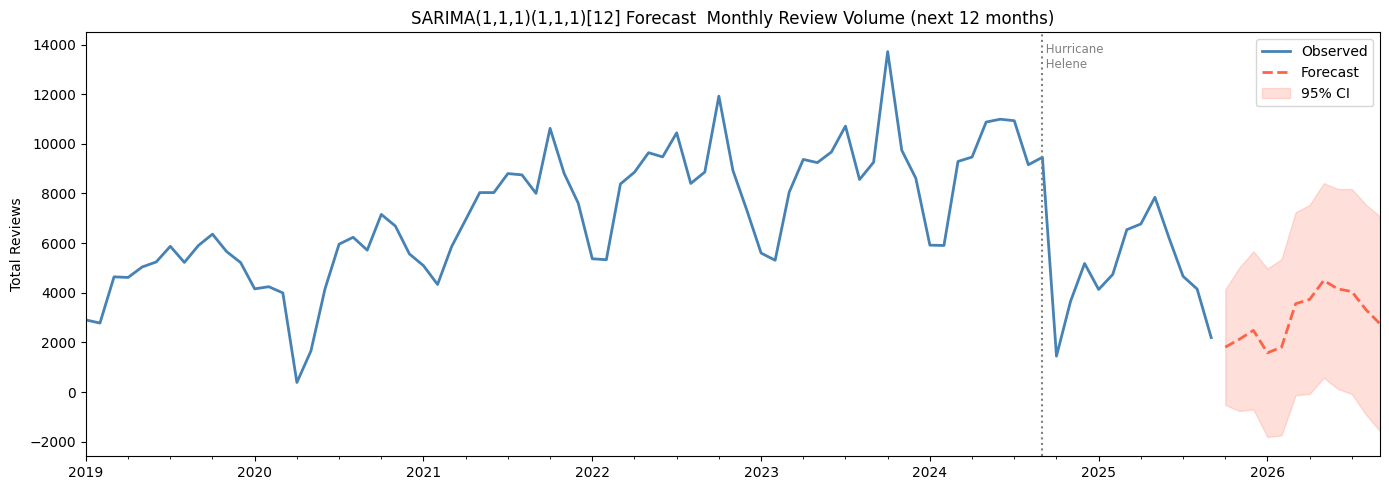

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ts['2019':].plot(ax=ax, color='steelblue', linewidth=2, label='Observed')
forecast_mean.plot(ax=ax, color='tomato', linewidth=2, linestyle='--', label='Forecast')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='tomato', alpha=0.2, label='95% CI')
ax.axvline(helene_date, color='gray', linestyle=':', linewidth=1.5)
ax.text(helene_date, ax.get_ylim()[1] * 0.97, ' Hurricane\n Helene',
        color='gray', fontsize=8.5, va='top')
ax.set_title('SARIMA(1,1,1)(1,1,1)[12] Forecast  Monthly Review Volume (next 12 months)')
ax.set_ylabel('Total Reviews')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.savefig("monthly_reviews_forecast.png", dpi=150, bbox_inches="tight") 
plt.show()

### performance dataframe

In [15]:
performance_df = (
    occupancy_per_listing
    .merge(revenue_df[['listing_id', 'price_clean', 'monthly_revenue_proxy']], 
           on='listing_id', how='left')
    .merge(avg_review_velocity, 
           on='listing_id', how='left')
)

# then merge with listings to add your independent variables
model_df = performance_df.merge(
    listings[['id', 'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
              'minimum_nights', 'host_is_superhost', 'host_identity_verified',
              'host_response_rate', 'host_acceptance_rate', 'host_listings_count',
              'instant_bookable', 'review_scores_rating', 'review_scores_cleanliness',
              'review_scores_location', 'review_scores_value', 'neighbourhood_cleansed']],
    left_on='listing_id',
    right_on='id',
    how='left'
)


# Exploring the Data


We have the following datasets:


- Listings 
  - 5,728 listings, 76 features
  - including hosts from airbnb's founding date in 2008


- Calendar 
  - 1,041,345 calendar records, 5 features


- Neighborhoods 
  - 8 neighborhoods (North, South, East, West, Arden, Candler, Fletcher, Downtown/Central) 


- Reviews 
  - 642,866 reviews , 6 features
  - Both recent and archived data was taken into account, with reviews ranging from July 2011 to September 2025

In [16]:
print('Reviews date')
print(reviews['date'].describe())
print('================================')



Reviews date
count                        642866
mean     2021-12-06 23:25:05.808052
min             2011-07-31 00:00:00
25%             2020-06-07 00:00:00
50%             2022-05-02 00:00:00
75%             2023-10-25 00:00:00
max             2025-09-21 00:00:00
Name: date, dtype: object


In [17]:
cols= ['first_review', 'last_review', 'calendar_last_scraped', 'host_since', 'last_scraped']
for col in cols:
    print('column:', col)
    print(listings[col].describe())
    print('================================')

column: first_review
count           5222
unique          1570
top       2024-09-02
freq              22
Name: first_review, dtype: object
column: last_review
count           5222
unique           598
top       2025-09-01
freq             247
Name: last_review, dtype: object
column: calendar_last_scraped
count           5728
unique             3
top       2025-06-17
freq            2875
Name: calendar_last_scraped, dtype: object
column: host_since
count           5725
unique          1490
top       2018-01-11
freq             228
Name: host_since, dtype: object
column: last_scraped
count           5728
unique             3
top       2025-06-17
freq            2875
Name: last_scraped, dtype: object


In [18]:
calendar.info()

<class 'pandas.DataFrame'>
Index: 1041345 entries, 0 to 520854
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   listing_id      1041345 non-null  int64         
 1   date            1041345 non-null  datetime64[us]
 2   available       1041345 non-null  float64       
 3   price           0 non-null        float64       
 4   adjusted_price  0 non-null        float64       
 5   minimum_nights  1041345 non-null  int64         
 6   maximum_nights  1041345 non-null  int64         
 7   occupancy_30d   1001417 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 71.5 MB


In [19]:
#calendar cleaning
#1040980 in recent; 365 in archived; 1041345 total


# drop adjusted price column since it has 100% null values
if 'adjusted_price' in calendar.columns:
    calendar['adjusted_price'].isnull().sum()/len(calendar)
    calendar.drop(columns=['adjusted_price'], inplace=True)

#drop price column since it has 100% null values
if 'price' in calendar.columns:
    calendar['price'].isnull().sum()/len(calendar)
    calendar.drop(columns=['price'], inplace=True)

# date to datetime
calendar['date'] = pd.to_datetime(calendar['date'])

# binary values in available column are currently 't' and 'f', so we will replace them with 1 and 0
calendar['available'] = calendar['available'].replace({'t': 1, 'f': 0})

#turning available into int
calendar['available'] = calendar['available'].astype(int)

calendar.info()
calendar.describe()

<class 'pandas.DataFrame'>
Index: 1041345 entries, 0 to 520854
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   listing_id      1041345 non-null  int64         
 1   date            1041345 non-null  datetime64[us]
 2   available       1041345 non-null  int64         
 3   minimum_nights  1041345 non-null  int64         
 4   maximum_nights  1041345 non-null  int64         
 5   occupancy_30d   1001417 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 55.6 MB


,listing_id,date,available,minimum_nights,maximum_nights,occupancy_30d
count,1.041345e+06,1041345,1.041345e+06,1.041345e+06,1.041345e+06,1.001417e+06
mean,4.969128e+17,2026-03-22 23:16:05.299684,6.135411e-01,6.592270e+00,6.405132e+02,3.832541e-01
min,1.553050e+05,2025-06-27 00:00:00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.352277e+07,2025-12-22 00:00:00,0.000000e+00,2.000000e+00,1.800000e+02,0.000000e+00
50%,5.357007e+07,2026-03-23 00:00:00,1.000000e+00,2.000000e+00,3.650000e+02,1.000000e-01
75%,1.000762e+18,2026-06-22 00:00:00,1.000000e+00,3.000000e+00,1.125000e+03,1.000000e+00
max,1.513870e+18,2026-09-21 00:00:00,1.000000e+00,7.300000e+02,1.125000e+03,1.000000e+00
std,5.461964e+17,NaN,4.869380e-01,2.035107e+01,4.705566e+02,4.393259e-01


In [20]:
# listing cleaning
# each of these had all null values, so we can drop them

if 'license' in listings.columns:
    listings['license'].isnull().sum()/len(listings)
    listings.drop(columns=['license'], inplace=True)


if 'calendar_updated' in listings.columns:
    listings['calendar_updated'].isnull().sum()/len(listings)
    listings.drop(columns=['calendar_updated'], inplace=True)



if 'neighbourhood_group_cleansed' in listings.columns:
    listings['neighbourhood_group_cleansed'].isnull().sum()/len(listings)
    listings.drop(columns=['neighbourhood_group_cleansed'], inplace=True)

#dropping has_availability column since it has 100% 't' values
if 'has_availability' in listings.columns:
    listings['has_availability'].value_counts(normalize=True)
    listings.drop(columns=['has_availability'], inplace=True)



# listings_recent.shape # 2852 in recent; 
# listings_archived.shape # 2876 in archived;
# listings.shape # 5728 total
# listings.shape
listings.info()
# putting the column names in a list to make it easier to check for null values


<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5728 non-null   int64  
 1   listing_url                                   5728 non-null   str    
 2   scrape_id                                     5728 non-null   int64  
 3   last_scraped                                  5728 non-null   str    
 4   source                                        5728 non-null   str    
 5   name                                          5728 non-null   str    
 6   description                                   5630 non-null   str    
 7   neighborhood_overview                         3796 non-null   str    
 8   picture_url                                   5728 non-null   str    
 9   host_id                                       5728 non-null   int64  
 10 

In [21]:
listings_columns = listings.columns.tolist() 
listings_columns

for col in ['price', 'host_response_rate', 'host_acceptance_rate']:
    if col in listings.columns and listings[col].dtype == 'str':
        listings[col] = listings[col].str.replace('$', '').str.replace(',', '').str.replace('%', '').astype(float)

for col in ['host_since', 'first_review', 'last_review', 'last_scraped', 'calendar_last_scraped']:
        listings[col] = pd.to_datetime(listings[col])
    

# for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 
#                'instant_bookable']:
#         listings[col] = listings[col].replace({'t': True, 'f': False})

listings.info()



<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            5728 non-null   int64         
 1   listing_url                                   5728 non-null   str           
 2   scrape_id                                     5728 non-null   int64         
 3   last_scraped                                  5728 non-null   datetime64[us]
 4   source                                        5728 non-null   str           
 5   name                                          5728 non-null   str           
 6   description                                   5630 non-null   str           
 7   neighborhood_overview                         3796 non-null   str           
 8   picture_url                                   5728 non-null   str           
 9

In [22]:
# sorting columns in listings by the number of rull values in each column, from most to least
listings.isnull().sum().sort_values(ascending=False)

# putting these in a list where values are >0 
listings_nulls = listings.isnull().sum().sort_values(ascending=False)
listings_nulls = listings_nulls[listings_nulls > 500]
listings_nulls

host_neighbourhood             3541
host_about                     2025
neighborhood_overview          1932
neighbourhood                  1932
host_location                   903
host_response_time              807
host_response_rate              807
beds                            655
price                           655
price_clean                     655
estimated_revenue_l365d         655
bathrooms                       637
review_scores_cleanliness       506
first_review                    506
review_scores_rating            506
review_scores_accuracy          506
review_scores_location          506
review_scores_checkin           506
reviews_per_month               506
last_review                     506
review_scores_communication     506
review_scores_value             506
dtype: int64

In [23]:
listings['beds'].describe()

count    5073.000000
mean        2.794599
std         2.440619
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        50.000000
Name: beds, dtype: float64

In [24]:
# showing the listing with the max beds 
listings[listings['beds'] == listings['beds'].max()]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
2594,1339091513653409760,https://www.airbnb.com/rooms/1339091513653409760,20250922033920,2025-09-22,city scrape,Asheville River Cabins,Imagine your family reunion or group retreat s...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,477251437,...,NaN,NaN,NaN,f,8,8,0,0,NaN,6847.0
5553,1339091513653409760,https://www.airbnb.com/rooms/1339091513653409760,20250617145515,2025-06-17,city scrape,Asheville River Cabins,Imagine your family reunion or group retreat s...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,477251437,...,NaN,NaN,NaN,f,8,8,0,0,NaN,6846.0


In [25]:
# reviews 
# reviews_recent.info() #324317 in recent; 318548 in archived
# reviews_archived.info() #318548 in archived
reviews.info() #642865 total
reviews['date'] = pd.to_datetime(reviews['date'])

<class 'pandas.DataFrame'>
RangeIndex: 642866 entries, 0 to 642865
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     642866 non-null  int64         
 1   id             642866 non-null  int64         
 2   date           642866 non-null  datetime64[us]
 3   reviewer_id    642866 non-null  int64         
 4   reviewer_name  642866 non-null  str           
 5   comments       642758 non-null  str           
 6   year_month     642866 non-null  period[M]     
dtypes: datetime64[us](1), int64(3), period[M](1), str(2)
memory usage: 34.3 MB


In [26]:
# neighborhood cleaning
if 'neighbourhood_group' in neighborhoods.columns:
    neighborhoods['neighbourhood_group'].isnull().sum()/len(neighborhoods)
    neighborhoods.drop(columns=['neighbourhood_group'], inplace=True)

# add column to include neighborhood names

zip_to_name = {
    28704: 'Arden',
    28715: 'Candler',
    28732: 'Fletcher',
    28801: 'Asheville - Downtown/Central',
    28803: 'Asheville - South',
    28804: 'Asheville - North',
    28805: 'Asheville - East',
    28806: 'Asheville - West'
}

#creating new neighbourhood_name column by mapping the neighbourhood column to the zip_to_name dictionary
neighborhoods['neighbourhood_name'] = neighborhoods['neighbourhood'].astype(int).map(zip_to_name)
# neighborhoods

neighborhoods.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   neighbourhood       8 non-null      int64
 1   neighbourhood_name  8 non-null      str  
dtypes: int64(1), str(1)
memory usage: 260.0 bytes


In [27]:
master_df = pd.concat([listings, reviews, neighborhoods, calendar], axis=1)

master_df.shape

(1041345, 91)

In [28]:
master_df.info()

<class 'pandas.DataFrame'>
Index: 1041345 entries, 0 to 1009954
Data columns (total 91 columns):
 #   Column                                        Non-Null Count    Dtype         
---  ------                                        --------------    -----         
 0   id                                            5728 non-null     float64       
 1   listing_url                                   5728 non-null     str           
 2   scrape_id                                     5728 non-null     float64       
 3   last_scraped                                  5728 non-null     datetime64[us]
 4   source                                        5728 non-null     str           
 5   name                                          5728 non-null     str           
 6   description                                   5630 non-null     str           
 7   neighborhood_overview                         3796 non-null     str           
 8   picture_url                                   5728 non-nul

# Market Supply

# Measuring Host Success

- Occupancy Rate: How filled are the listings?

Questions: 
- How many listings exist? Are more being added over time?
- What types of properties are listed (entire home, private room, etc.)?
- How many nights are hosts making available on their calendar?
- Which neighborhoods have the most listings?



## Which neighborhood has the most listings?


In [29]:

# Count listings per neighborhood and calculate metrics
listings_per_neighborhood = listings.groupby('neighbourhood_cleansed').agg(
    num_listings=('id', 'size'),
    avg_price=('price', 'mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_rating=('review_scores_rating', 'mean')
).reset_index().round(2)

# Create a dict for quick lookup
metrics_dict = listings_per_neighborhood.set_index('neighbourhood_cleansed').to_dict('index')

# Add metrics to geojson properties
for feature in neighborhoods_geo['features']:
    neigh = feature['properties']['neighbourhood']
    try:
        metrics_key = int(neigh)
    except (ValueError, TypeError):
        metrics_key = neigh

    if metrics_key in metrics_dict:
        feature['properties'].update(metrics_dict[metrics_key])
    else:
        feature['properties'].update({'num_listings': 0, 'avg_price': 0, 'avg_reviews': 0, 'avg_rating': 0})

    feature['properties']['neighbourhood_name'] = zip_to_name.get(metrics_key, neigh)

# Create a folium map centered on Asheville
m = folium.Map(location=[35.5951, -82.5515], zoom_start=11,tiles="CartoDB positron")

# Add choropleth layer
folium.Choropleth(
    geo_data=neighborhoods_geo,
    data=listings_per_neighborhood,
    columns=['neighbourhood_cleansed', 'num_listings'],
    key_on='feature.properties.neighbourhood',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Listings'
).add_to(m)

# Add tooltips with metrics
folium.GeoJson(
    neighborhoods_geo,
    style_function=lambda _: {'fillColor': 'transparent', 'color': 'black', 'weight': 1},
    tooltip=folium.GeoJsonTooltip(
        fields=['neighbourhood_name', 'num_listings', 'avg_price', 'avg_reviews', 'avg_rating'],
        aliases=['Neighborhood:', 'Number of Listings:', 'Avg Price ($):', 'Avg Reviews:', 'Avg Rating:'],
        localize=True
    )
).add_to(m)

# Display the map
m

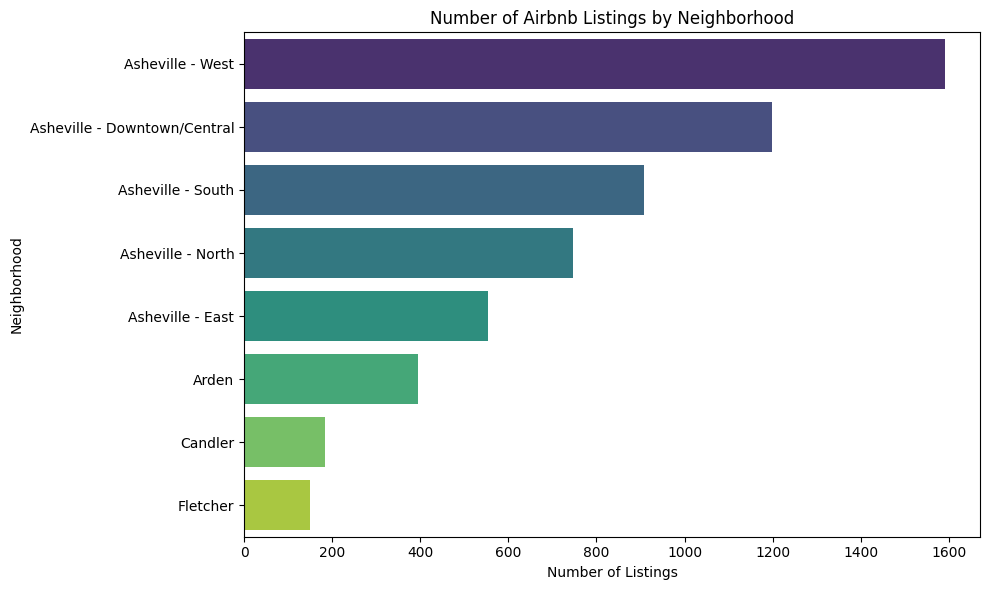

In [30]:
# creating a bar chart to show the number of listings per neighborhood
plot_df = listings_per_neighborhood.copy()
plot_df['neighborhood_name'] = plot_df['neighbourhood_cleansed'].map(zip_to_name)
plot_df = plot_df.sort_values('num_listings', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y='neighborhood_name', x='num_listings', hue='neighborhood_name', palette='viridis', legend=False)
plt.title('Number of Airbnb Listings by Neighborhood')
plt.xlabel('Number of Listings')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.savefig("number_of_listings.png", dpi=150, bbox_inches="tight") 
plt.show()

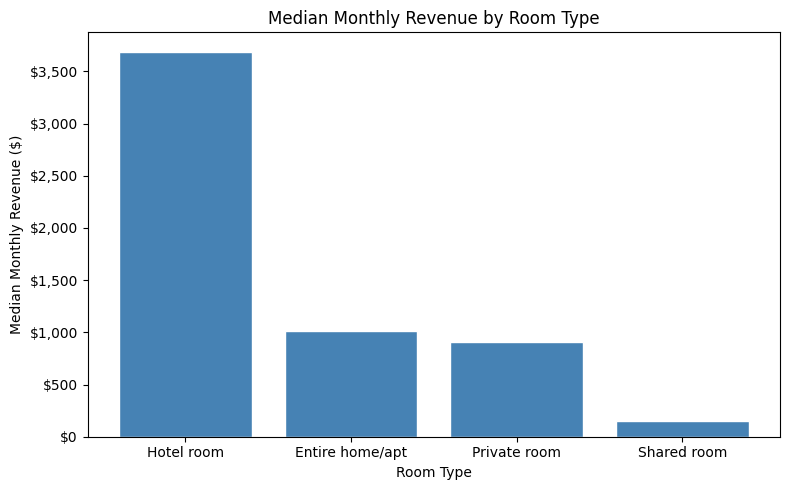

In [31]:
# merge room_type into revenue_df
revenue_by_room = (
    revenue_df
    .merge(listings[["id", "room_type"]], left_on="listing_id", right_on="id", how="left")
    .groupby("room_type")["monthly_revenue_proxy"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(revenue_by_room["room_type"], revenue_by_room["monthly_revenue_proxy"],
       color="steelblue", edgecolor="white")
ax.set_title("Median Monthly Revenue by Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("Median Monthly Revenue ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("median_monthly_revenue_by_room_type.png", dpi=150, bbox_inches="tight") 
plt.show()

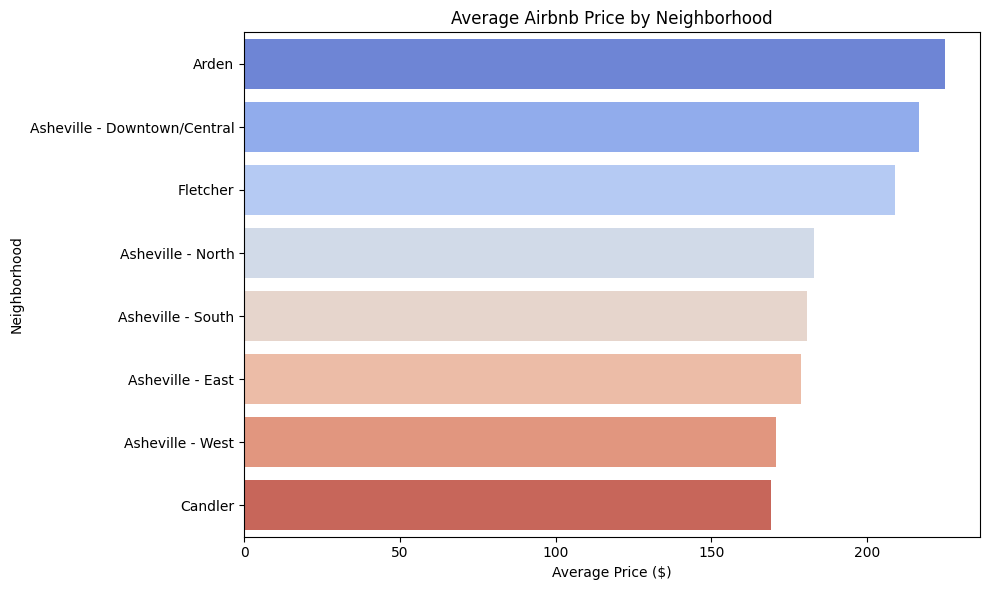

In [32]:
# creating a bar chart to show the average price per neighborhood
price_df = listings_per_neighborhood.copy()
price_df['neighborhood_name'] = price_df['neighbourhood_cleansed'].map(zip_to_name)
price_df = price_df.sort_values('avg_price', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=price_df, y='neighborhood_name', x='avg_price', hue='neighborhood_name', palette='coolwarm', legend=False)
plt.title('Average Airbnb Price by Neighborhood')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.savefig("average_price_by_neighborhood.png", dpi=150, bbox_inches="tight") 
plt.show()

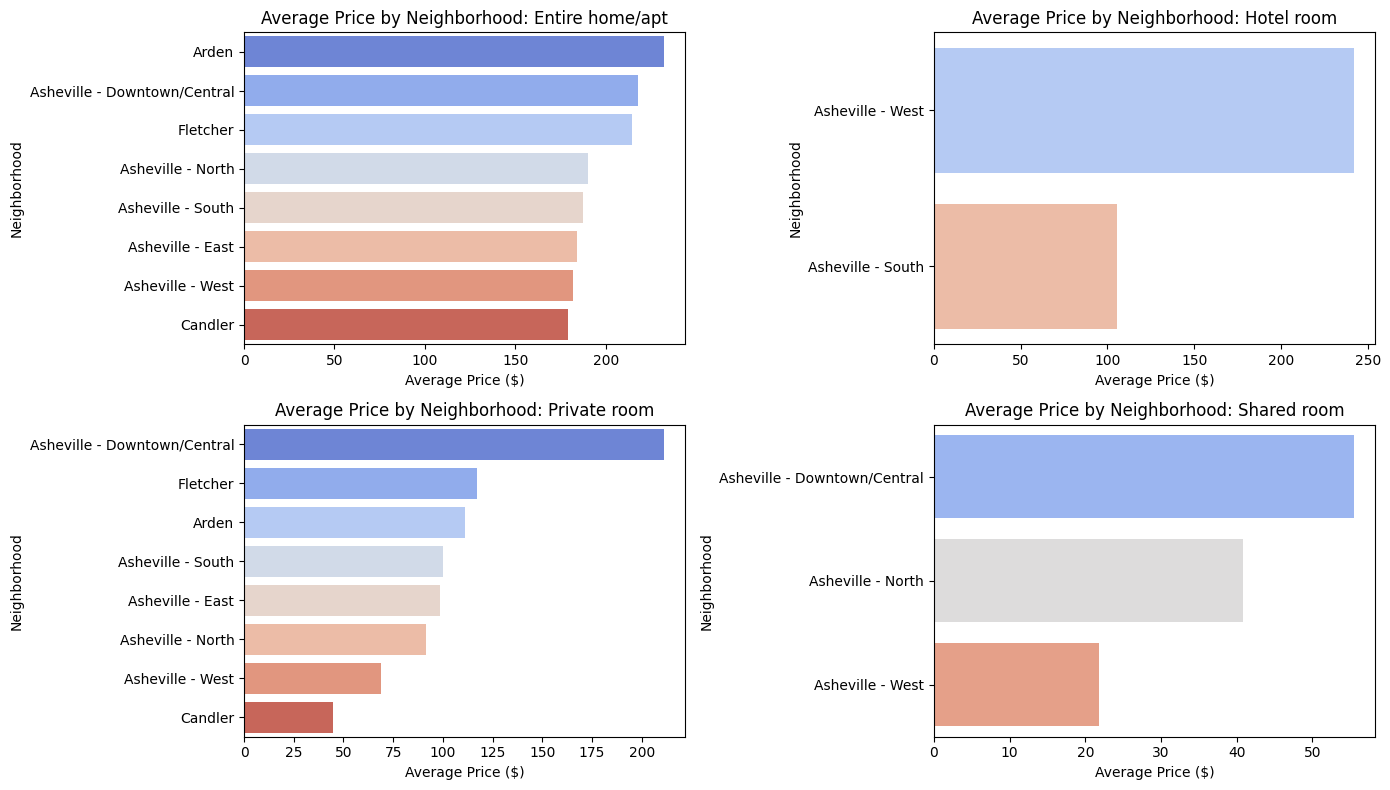

In [33]:
# creating separate bar charts to show average price per neighborhood for each room type
price_by_room = (
    listings
    .groupby(['neighbourhood_cleansed', 'room_type'])
    .agg(avg_price=('price', 'mean'))
    .reset_index()
)
price_by_room['neighborhood_name'] = price_by_room['neighbourhood_cleansed'].map(zip_to_name)
room_types = sorted(price_by_room['room_type'].unique())

n_rooms = len(room_types)
n_cols = 2
n_rows = (n_rooms + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4), sharex=False)
axes = axes.flatten()

for ax, room_type in zip(axes, room_types):
    room_df = price_by_room[price_by_room['room_type'] == room_type].sort_values('avg_price', ascending=False)
    sns.barplot(
        data=room_df,
        y='neighborhood_name',
        x='avg_price',
        hue='neighborhood_name',
        palette='coolwarm',
        legend=False,
        ax=ax
    )
    ax.set_title(f'Average Price by Neighborhood: {room_type}')
    ax.set_xlabel('Average Price ($)')
    ax.set_ylabel('Neighborhood')

for ax in axes[n_rooms:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig("average_price_by_neighborhood.png", dpi=150, bbox_inches="tight") 
plt.show()

## What Drives Airbnb Occupancy in Asheville? 

8 features: 
- Room Type
- Accommodates (number of people)
- Bedrooms
- Host is Superhost
- Instant Bookable
- Review Score Rating
- Neighborhood
- Price ($/night)


## Random Forest Model

### prep

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = [
    # property characteristics
    'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    # booking friction
    'minimum_nights',
    # host quality signals
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate', 'host_acceptance_rate', 'host_listings_count',
    # guest experience signals
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    # listing context
    'instant_bookable', 'neighbourhood_cleansed', 'price_clean'
]
target = 'occupancy_rate'

# drop rows missing target or features
model_df_clean = model_df[features + [target]].dropna().copy()

# convert rates from 0-100 scale to 0-1 decimal
rate_cols = ['host_response_rate', 'host_acceptance_rate']
for col in rate_cols:
    model_df_clean[col] = model_df_clean[col].str.rstrip('%').astype(float) / 100

# dummy encode categoricals (drop_first avoids multicollinearity)
cat_cols = ['room_type', 'neighbourhood_cleansed', 'host_is_superhost',
            'host_identity_verified', 'instant_bookable']
model_df_clean = pd.get_dummies(model_df_clean, columns=cat_cols, drop_first=True)

X = model_df_clean.drop(columns=[target])
y = model_df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {X_train.shape[0]} rows, {X_train.shape[1]} features")


Training on 6262 rows, 26 features


### building/training model

In [35]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=200, random_state=621, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred       = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

r2_test  = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)
rmse     = root_mean_squared_error(y_test, y_pred)
cv_r2    = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)

summary = pd.DataFrame({
    'Metric': ['R² (train)', 'R² (test)', 'RMSE (test)', 'CV R² mean', 'CV R² std',
               'n_train', 'n_test', 'n_features', 'n_estimators'],
    'Value': [f'{r2_train:.3f}', f'{r2_test:.3f}', f'{rmse:.3f}',
              f'{cv_r2.mean():.3f}', f'{cv_r2.std():.3f}',
              X_train.shape[0], X_test.shape[0], X_train.shape[1], rf.n_estimators]
})
summary


,Metric,Value
0,R² (train),0.976
1,R² (test),0.842
2,RMSE (test),0.117
3,CV R² mean,0.071
4,CV R² std,0.116
5,n_train,6262
6,n_test,1566
7,n_features,26
8,n_estimators,200


In [37]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances.head(20)

,feature,importance
12,price_clean,0.133795
7,host_listings_count,0.133458
11,review_scores_value,0.093364
10,review_scores_location,0.083799
9,review_scores_cleanliness,0.083694
6,host_acceptance_rate,0.071983
8,review_scores_rating,0.065696
0,accommodates,0.051001
4,minimum_nights,0.039084
3,beds,0.031715


### visuals

In [38]:
feature_labels = {
    'room_type': 'Room Type',
    'accommodates': 'Accommodates',
    'bedrooms': 'Bedrooms',
    'host_is_superhost': 'Host is Superhost',
    'instant_bookable': 'Instant Bookable',
    'review_scores_rating': 'Review Score Rating',
    'neighbourhood_cleansed': 'Neighborhood',
    'price_clean': 'Price ($/night)',
    'host_listings_count': 'Host Listings Count',
    'host_identity_verified': 'Host Identity Verified',
    'host_response_rate': 'Host Response Rate',
    'host_acceptance_rate': 'Host Acceptance Rate',
    'bathrooms': 'Bathrooms',
    'beds': 'Beds',
    'minimum_nights': 'Minimum Nights',
    'review_scores_value': 'Review Score Value',
    'review_scores_location': 'Review Score Location',
    'review_scores_cleanliness': 'Review Score Cleanliness',
    'instant_bookable_t': 'Instant Bookable',
    'neighbourhood_cleansed_28801': 'Downtown AVL',
    'neighbourhood_cleansed_28803': 'South AVL',
    'neighbourhood_cleansed_28804': 'North AVL',
    'neighbourhood_cleansed_28805': 'East AVL',
    'neighbourhood_cleansed_28806': 'West AVL',
    'neighbourhood_cleansed_28715': 'Candler',
    'neighbourhood_cleansed_28732': 'Fletcher',
    'neighbourhood_cleansed_28704': 'Arden',
    'room_type_Hotel room': 'Room Type: Hotel Room',
    'room_type_Private room': 'Room Type: Private Room',
    'room_type_Shared room': 'Room Type: Shared Room',
    'host_is_superhost_t': 'Host is Superhost',
    'host_identity_verified_t': 'Host Identity Verified'
}


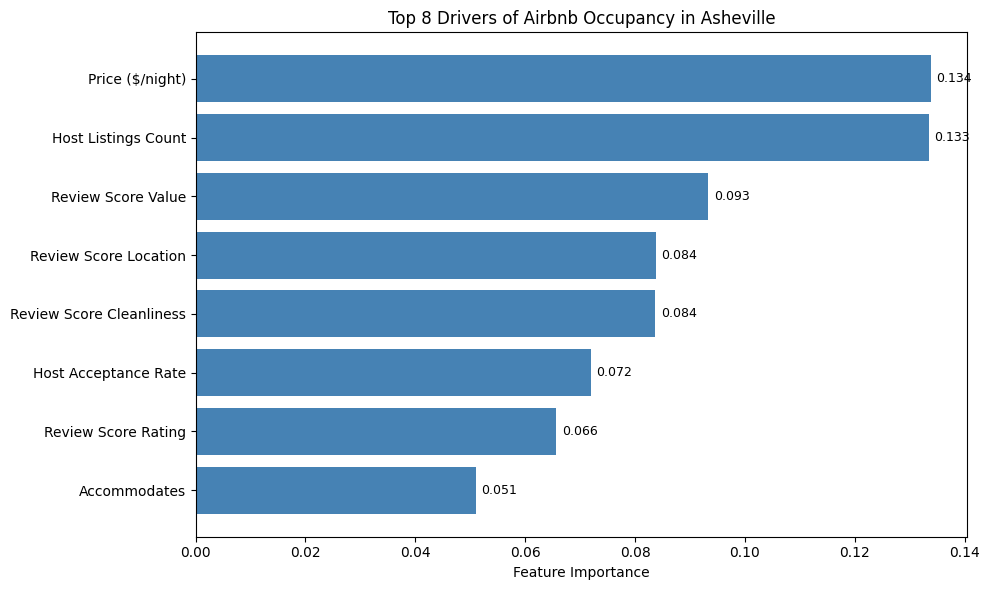

In [39]:

importances = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .rename(index=feature_labels)
    .sort_values(ascending=False)
    .head(8)
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'index': 'Feature', 0: 'Importance'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances['Feature'], importances['Importance'], color='steelblue')
ax.set_title('Top 8 Drivers of Airbnb Occupancy in Asheville')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

for i, v in enumerate(importances['Importance']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight") 
plt.show()


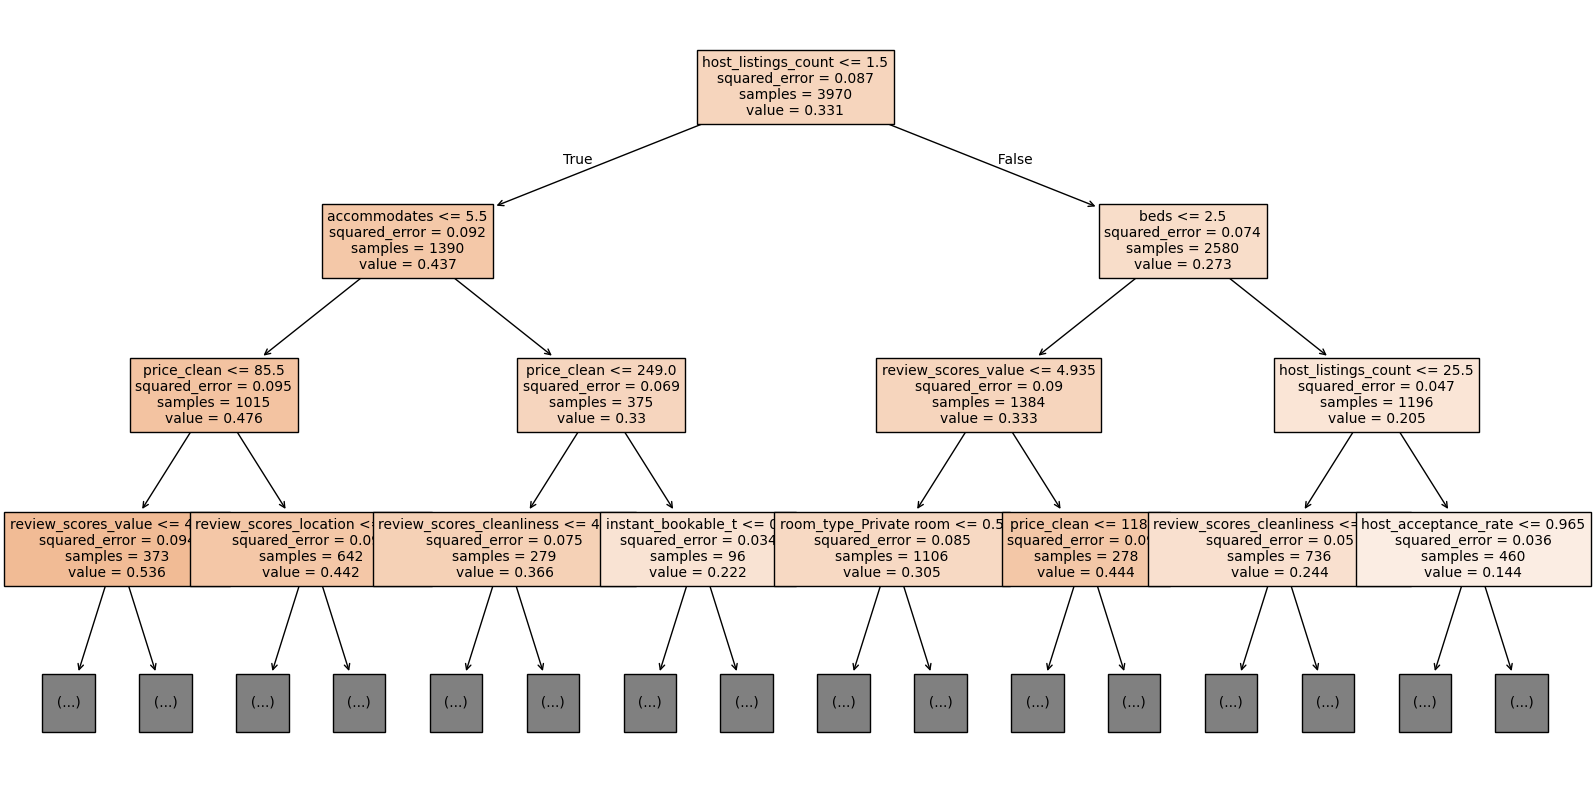

In [40]:
from sklearn import tree

# Visualize the first tree in the forest
plt.figure(figsize=(20,10))
tree.plot_tree(rf.estimators_[0], feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
plt.show()


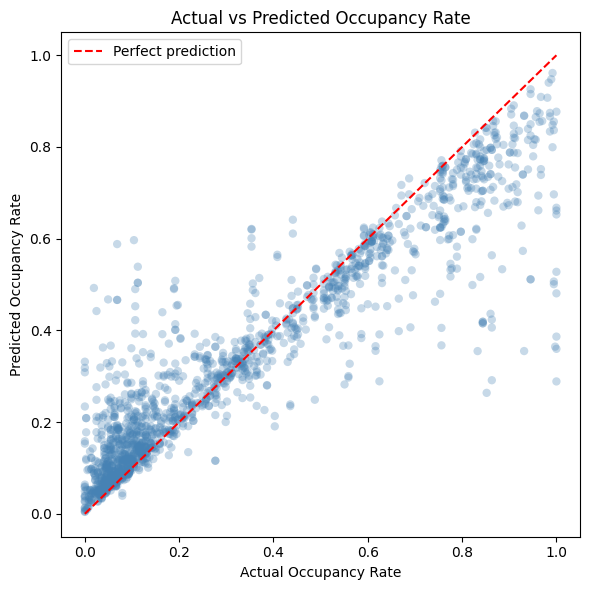

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Occupancy Rate')
ax.set_ylabel('Predicted Occupancy Rate')
ax.set_title('Actual vs Predicted Occupancy Rate')
ax.legend()
plt.tight_layout()
plt.show()

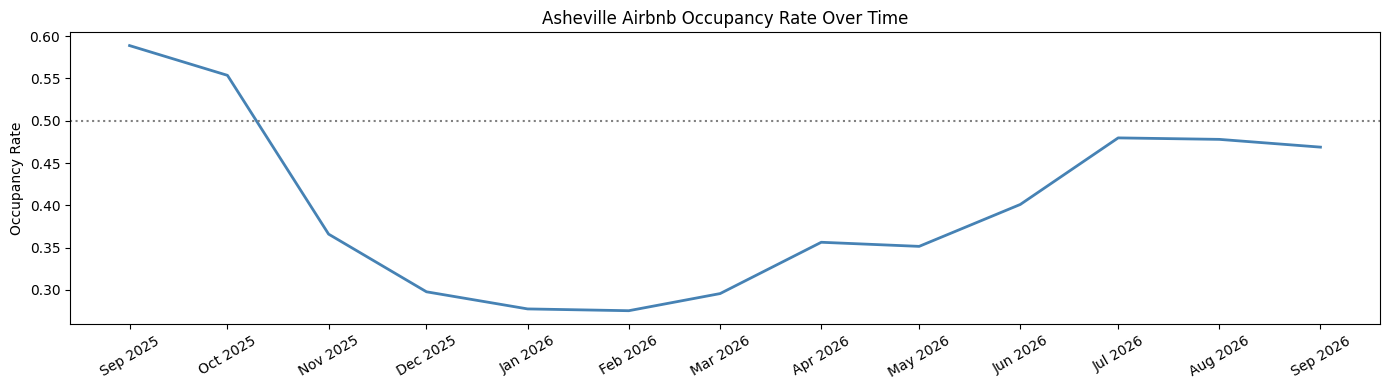

In [42]:
import matplotlib.dates as mdates

# merge calendar with neighborhood info via listings
calendar_enriched = calendar.merge(
    listings[["id", "neighbourhood_cleansed"]],
    left_on="listing_id", right_on="id",
    how="left"
)

monthly_occupancy = (
    calendar_enriched
    .groupby(calendar_enriched["date"].dt.to_period("M"))["available"]
    .mean()
    .reset_index()
)
monthly_occupancy["available"] = 1 - monthly_occupancy["available"]
monthly_occupancy["date"] = monthly_occupancy["date"].dt.to_timestamp()
monthly_occupancy = monthly_occupancy[monthly_occupancy["date"] >= "2025-09-01"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_occupancy["date"], monthly_occupancy["available"], 
        color="steelblue", linewidth=2)
ax.axhline(y=0.50, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("Asheville Airbnb Occupancy Rate Over Time")
ax.set_ylabel("Occupancy Rate")
ax.set_xlabel("")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("occupancy_rate_over_time.png", dpi=150, bbox_inches="tight") 
plt.show()

## neighborhood overview
searching for common themes in neighborhood overviews


In [43]:
# do text analysis on neighborhood overview column to see if there are any common themes or keywords that could be used to create a new feature for the listings dataset
listings['neighborhood_overview']

0       We are within easy walk of pubs, breweries, mu...
1                                                     NaN
2       Our beautiful Grove Park Historic District clo...
3                                                     NaN
4       City vibes with country appeal. Peaceful neigh...
                              ...                        
5723    Aura sits in one of Asheville’s most coveted r...
5724                                                  NaN
5725    The beautiful historical Shiloh neighborhood b...
5726                                                  NaN
5727                                                  NaN
Name: neighborhood_overview, Length: 5728, dtype: str

# Market Demand
The guest's side of the market 

(ex: avg ocupancy rate, avg monthly reviews per listing)

Questions:
- Of the available nights, how many are actually booked?
- Are review counts (a proxy for bookings) going up or down over time?
- Which listings or neighborhoods are most sought after?
- Are there seasonal spikes in demand (e.g., fall foliage in Asheville)?



# Customer Comments 
(ex topics, sentiments)

In [ ]:
# =============================================================================
# CUSTOMER COMMENTS: VADER Sentiment + LDA Topic Modeling
# Assumes: reviews, listings DataFrames already loaded; zip_to_name dict defined
# =============================================================================

# ── 0. Install / import ──────────────────────────────────────────────────────
# !pip install vaderSentiment gensim pyLDAvis

## Section 1 VADER Sentiment Analysis

In [45]:
# ── 1a. Score every review ───────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()

# Work on a copy; drop rows with no text
reviews_clean = reviews.dropna(subset=["comments"]).copy()
reviews_clean["comments"] = reviews_clean["comments"].astype(str)

# Apply VADER — compound score ∈ [-1, 1]
reviews_clean["vader_compound"] = reviews_clean["comments"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

# Categorical sentiment label
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["sentiment"] = reviews_clean["vader_compound"].apply(label_sentiment)

print(f"Scored {len(reviews_clean):,} reviews")
print(reviews_clean["sentiment"].value_counts(normalize=True).map("{:.1%}".format))

Scored 642,758 reviews
sentiment
Positive    98.1%
Neutral      1.2%
Negative     0.7%
Name: proportion, dtype: str


In [46]:
# -- VADER: metrics summary ---------------------------------------------------
total = len(reviews_clean)
pos   = (reviews_clean["sentiment"] == "Positive").sum()
neg   = (reviews_clean["sentiment"] == "Negative").sum()
neu   = (reviews_clean["sentiment"] == "Neutral").sum()
avg   = reviews_clean["vader_compound"].mean()
med   = reviews_clean["vader_compound"].median()

print(f"""
VADER SENTIMENT METRICS
========================
Total reviews scored : {total:,}
Positive (score >= 0.05)  : {pos:,}  ({pos/total:.1%})
Neutral  (-0.05 to 0.05)  : {neu:,}  ({neu/total:.1%})
Negative (score <= -0.05) : {neg:,}  ({neg/total:.1%})
Mean compound score  : {avg:.4f}
Median compound score: {med:.4f}

VADER Compound Score:
  A single normalized score from -1 (most negative) to +1 (most positive).
  Thresholds: >= 0.05 = Positive, <= -0.05 = Negative, in between = Neutral.
  Scores near +1 are overwhelmingly positive (typical for Airbnb reviews).

No train/test split is needed:
  VADER is a rule-based lexicon — it assigns scores using a fixed dictionary
  of sentiment-weighted words. There is no model to train or overfit.
  Its strength is speed (642k reviews scored instantly) and interpretability.
  Its weakness is that it misses sarcasm, context, and domain-specific language
  (e.g., 'the host was not bad' may score lower than intended).
""")



VADER SENTIMENT METRICS
Total reviews scored : 642,758
Positive (score >= 0.05)  : 630,453  (98.1%)
Neutral  (-0.05 to 0.05)  : 8,024  (1.2%)
Negative (score <= -0.05) : 4,281  (0.7%)
Mean compound score  : 0.8515
Median compound score: 0.9217

VADER Compound Score:
  A single normalized score from -1 (most negative) to +1 (most positive).
  Thresholds: >= 0.05 = Positive, <= -0.05 = Negative, in between = Neutral.
  Scores near +1 are overwhelmingly positive (typical for Airbnb reviews).

No train/test split is needed:
  VADER is a rule-based lexicon — it assigns scores using a fixed dictionary
  of sentiment-weighted words. There is no model to train or overfit.
  Its strength is speed (642k reviews scored instantly) and interpretability.
  Its weakness is that it misses sarcasm, context, and domain-specific language
  (e.g., 'the host was not bad' may score lower than intended).



In [47]:
# ── 1b. Merge neighborhood info ──────────────────────────────────────────────
# Map listing_id → neighbourhood_cleansed → readable name
listing_neighborhood = listings[["id", "neighbourhood_cleansed"]].copy()
listing_neighborhood["neighbourhood_cleansed"] = (
    listing_neighborhood["neighbourhood_cleansed"].astype(float).astype(int)
)
listing_neighborhood["neighborhood_name"] = (
    listing_neighborhood["neighbourhood_cleansed"].map(zip_to_name)
)

reviews_geo = reviews_clean.merge(
    listing_neighborhood,
    left_on="listing_id",
    right_on="id",
    how="left"
)


In [48]:
# ── 1c. Aggregate sentiment by neighborhood ──────────────────────────────────
neighborhood_sentiment = (
    reviews_geo
    .groupby("neighborhood_name")
    .agg(
        avg_sentiment=("vader_compound", "mean"),
        median_sentiment=("vader_compound", "median"),
        pct_positive=("sentiment", lambda x: (x == "Positive").mean()),
        pct_negative=("sentiment", lambda x: (x == "Negative").mean()),
        review_count=("vader_compound", "count"),
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

print("\nSentiment by Neighborhood:")
print(neighborhood_sentiment.to_string(index=False))


Sentiment by Neighborhood:
           neighborhood_name  avg_sentiment  median_sentiment  pct_positive  pct_negative  review_count
            Asheville - East       0.864661            0.9295      0.985513      0.004544        124110
           Asheville - North       0.859692            0.9267      0.983253      0.005913        187559
            Asheville - West       0.852802            0.9217      0.981493      0.005836        345599
                       Arden       0.851809            0.9257      0.978711      0.006998         57870
           Asheville - South       0.848818            0.9213      0.979592      0.006723        191442
                     Candler       0.845526            0.9199      0.977968      0.009317         32952
Asheville - Downtown/Central       0.843148            0.9167      0.978803      0.008408        305795
                    Fletcher       0.838327            0.9144      0.975847      0.007025         25338


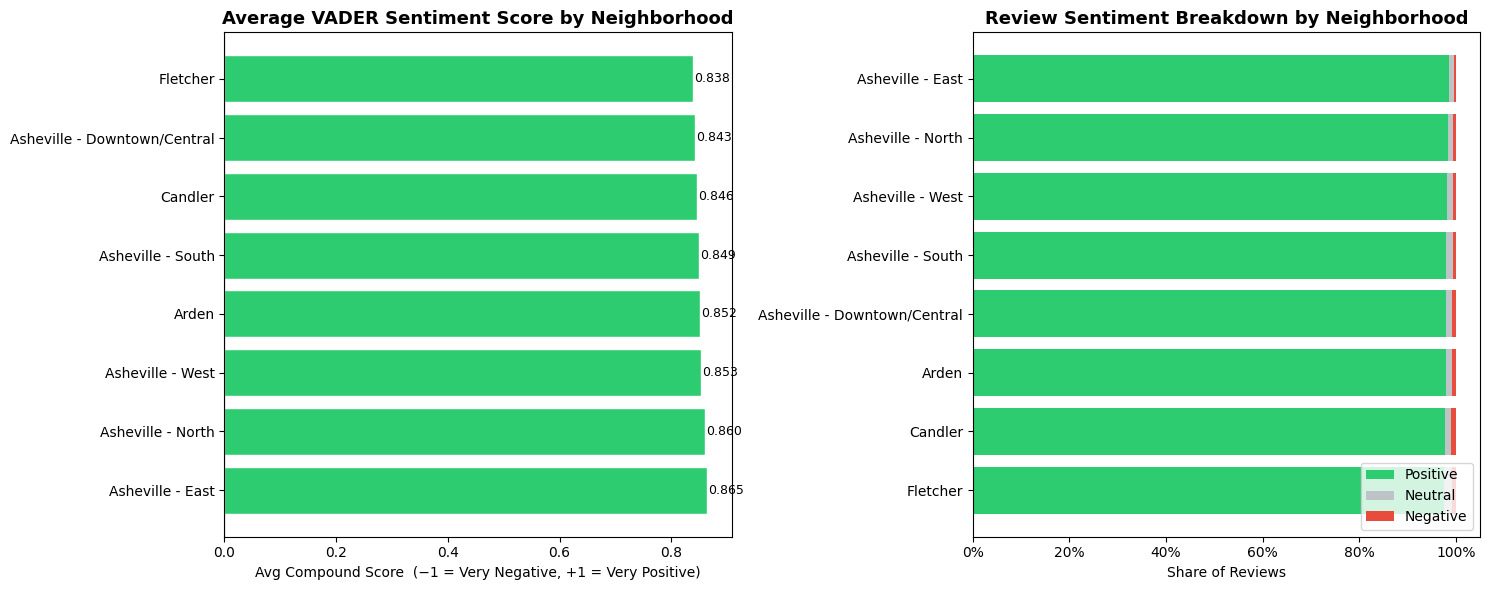

In [49]:
# ── 1d. Visualize: sentiment by neighborhood ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: avg compound score
ax = axes[0]
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in neighborhood_sentiment["avg_sentiment"]]
bars = ax.barh(
    neighborhood_sentiment["neighborhood_name"],
    neighborhood_sentiment["avg_sentiment"],
    color=colors, edgecolor="white"
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average VADER Sentiment Score by Neighborhood", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg Compound Score  (−1 = Very Negative, +1 = Very Positive)")
ax.set_ylabel("")
for bar, val in zip(bars, neighborhood_sentiment["avg_sentiment"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

# Right: stacked % positive / neutral / negative
ax = axes[1]
neighborhood_sentiment["pct_neutral"] = (
    1 - neighborhood_sentiment["pct_positive"] - neighborhood_sentiment["pct_negative"]
)
neigh_sorted = neighborhood_sentiment.sort_values("pct_positive", ascending=True)

ax.barh(neigh_sorted["neighborhood_name"], neigh_sorted["pct_positive"],
        color="#2ecc71", label="Positive")
ax.barh(neigh_sorted["neighborhood_name"], neigh_sorted["pct_neutral"],
        left=neigh_sorted["pct_positive"], color="#bdc3c7", label="Neutral")
ax.barh(neigh_sorted["neighborhood_name"],
        neigh_sorted["pct_negative"],
        left=neigh_sorted["pct_positive"] + neigh_sorted["pct_neutral"],
        color="#e74c3c", label="Negative")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Review Sentiment Breakdown by Neighborhood", fontsize=13, fontweight="bold")
ax.set_xlabel("Share of Reviews")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("sentiment_by_neighborhood.png", dpi=150, bbox_inches="tight")
plt.show()






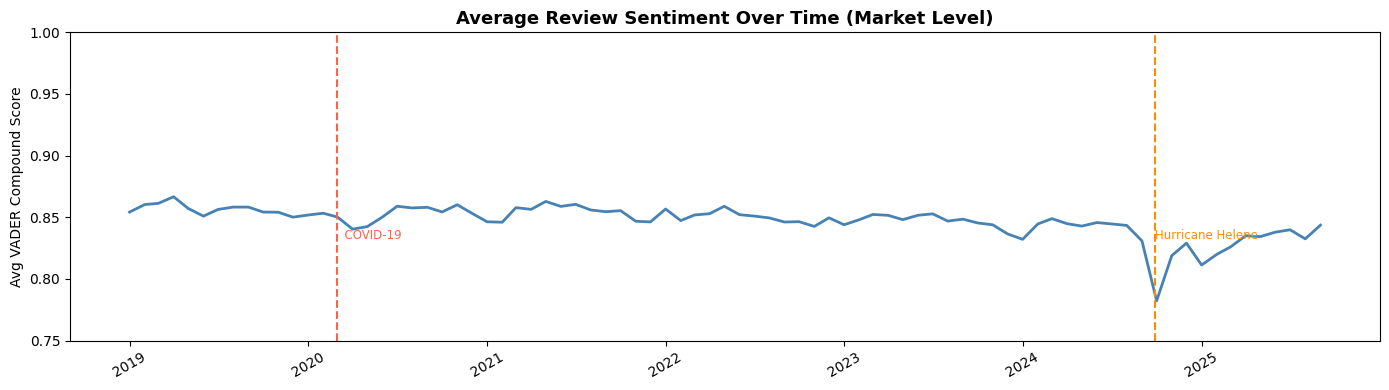

In [50]:
# -- 1e. Sentiment trend over time (market-level) ----------------------------
reviews_geo["date"] = pd.to_datetime(reviews_geo["date"])
reviews_geo["year_month"] = reviews_geo["date"].dt.to_period("M")

monthly_sentiment = (
    reviews_geo
    .groupby("year_month")["vader_compound"]
    .mean()
    .reset_index()
)
monthly_sentiment["year_month"] = monthly_sentiment["year_month"].dt.to_timestamp()
monthly_sentiment = monthly_sentiment[monthly_sentiment["year_month"] >= "2019-01-01"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_sentiment["year_month"], monthly_sentiment["vader_compound"],
        color="steelblue", linewidth=2)
ax.axvline(pd.Timestamp("2020-03-01"), color="tomato", linestyle="--", linewidth=1.5)
ax.text(pd.Timestamp("2020-03-01"), monthly_sentiment["vader_compound"].max() * 0.97,
        "  COVID-19", color="tomato", fontsize=8.5, va="top")
ax.axvline(pd.Timestamp("2024-09-27"), color="darkorange", linestyle="--", linewidth=1.5)
ax.text(pd.Timestamp("2024-09-27"), monthly_sentiment["vader_compound"].max() * 0.97,
        "Hurricane Helene", color="darkorange", fontsize=8.5, va="top")
ax.set_ylim(bottom=0.75, top = 1.0)
ax.set_title("Average Review Sentiment Over Time (Market Level)", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg VADER Compound Score")
ax.set_xlabel("")
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("sentiment_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 2 - LDA TOPIC MODELING

In [51]:

# ── 2a. Preprocessing ────────────────────────────────────────────────────────
# Custom stopwords: Airbnb-specific filler words that inflate every topic
AIRBNB_STOPWORDS = {
    "stay", "place", "host", "airbnb", "apartment", "room", "house",
    "great", "nice", "good", "perfect", "wonderful", "amazing", "love",
    "recommend", "back", "highly", "would", "could", "well", "also",
    "clean", "comfortable", "location", "everything", "really", "just",
    "trip", "time", "night", "definitely", "us", "we", "our", "like"
}
ALL_STOPWORDS = STOPWORDS.union(AIRBNB_STOPWORDS)

CUSTOM_FILTERS = [
    strip_tags,
    strip_punctuation,
    strip_numeric,
    strip_multiple_whitespaces,
    remove_stopwords,
]

def preprocess_review(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    tokens = preprocess_string(text, CUSTOM_FILTERS)
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 2]
    return tokens

print("Preprocessing reviews for LDA…")
# Sample up to 50k reviews for speed; use all if your machine can handle it
sample = reviews_clean.sample(min(50_000, len(reviews_clean)), random_state=42)
processed_docs = sample["comments"].apply(preprocess_review).tolist()
processed_docs = [doc for doc in processed_docs if len(doc) >= 3]

print(f"  {len(processed_docs):,} documents after preprocessing")


Preprocessing reviews for LDA…
  44,703 documents after preprocessing


In [52]:
# ── 2b. Build dictionary + corpus ────────────────────────────────────────────
dictionary = corpora.Dictionary(processed_docs)
# Filter extremes: ignore tokens in <5 docs or >50% of docs
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f"  Vocabulary size: {len(dictionary):,} tokens")


  Vocabulary size: 6,403 tokens


In [53]:
# ── 2c. Train LDA ────────────────────────────────────────────────────────────
N_TOPICS = 6      # 6 topics works well for Airbnb reviews; tune if needed
PASSES   = 10

print(f"Training LDA with {N_TOPICS} topics…")
lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=N_TOPICS,
    passes=PASSES,
    random_state=42,
    alpha="auto",
    eta="auto"
)
print("  Done.")


Training LDA with 6 topics…
  Done.


In [54]:
# -- LDA: metrics summary -----------------------------------------------------
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model, texts=processed_docs, dictionary=dictionary, coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
perplexity_score = lda_model.log_perplexity(corpus)

print(f"""
LDA TOPIC MODEL METRICS
========================
Coherence (C_v) : {coherence_score:.4f}
Perplexity      : {perplexity_score:.4f}

Coherence (C_v):
  Measures how semantically similar the top words within each topic are.
  Range is roughly 0 to 1 — higher is better.
  A score above 0.50 is generally acceptable; above 0.65 is strong.
  Low coherence means topics are a jumble of unrelated words and the
  number of topics (N_TOPICS) may need tuning.

Perplexity (log):
  Measures how surprised the model is by unseen documents — lower (less
  negative) is better in a relative sense. Reported as log-perplexity here.
  Perplexity alone is a poor guide for topic quality (it improves as you
  add more topics even when topics become meaningless). Always pair it
  with the coherence score and a manual review of the top words.
""")



LDA TOPIC MODEL METRICS
Coherence (C_v) : 0.5899
Perplexity      : -7.0094

Coherence (C_v):
  Measures how semantically similar the top words within each topic are.
  Range is roughly 0 to 1 — higher is better.
  A score above 0.50 is generally acceptable; above 0.65 is strong.
  Low coherence means topics are a jumble of unrelated words and the
  number of topics (N_TOPICS) may need tuning.

Perplexity (log):
  Measures how surprised the model is by unseen documents — lower (less
  negative) is better in a relative sense. Reported as log-perplexity here.
  Perplexity alone is a poor guide for topic quality (it improves as you
  add more topics even when topics become meaningless). Always pair it
  with the coherence score and a manual review of the top words.



In [55]:

# ── 2d. Print top words per topic ────────────────────────────────────────────
print("\n=== Top words per topic ===")
topic_labels = {
    0: "Mountain Views & Nature",
    1: "Amenity Quality",
    2: "Interior Space & Layout",
    3: "Asheville Location & Walkability",
    4: "Host Thoughtfulness & Extras",
    5: "Urban Convenience & Nightlife Access",
}

for topic_id in range(N_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ", ".join([w for w, _ in words])
    print(f"  Topic {topic_id}: {word_str}")




=== Top words per topic ===
  Topic 0: family, cabin, porch, views, view, mountains, deck, mountain, blue, ridge
  Topic 1: hot, tub, photos, old, don’t, year, pictures, pool, looks, description
  Topic 2: kitchen, bed, bathroom, small, overall, large, bedroom, shower, use, living
  Topic 3: asheville, downtown, home, close, space, loved, beautiful, easy, super, quiet
  Topic 4: coffee, touches, thoughtful, provided, extra, thought, feel, left, stocked, appreciated
  Topic 5: restaurants, walking, distance, walk, breweries, parking, street, shops, new, river


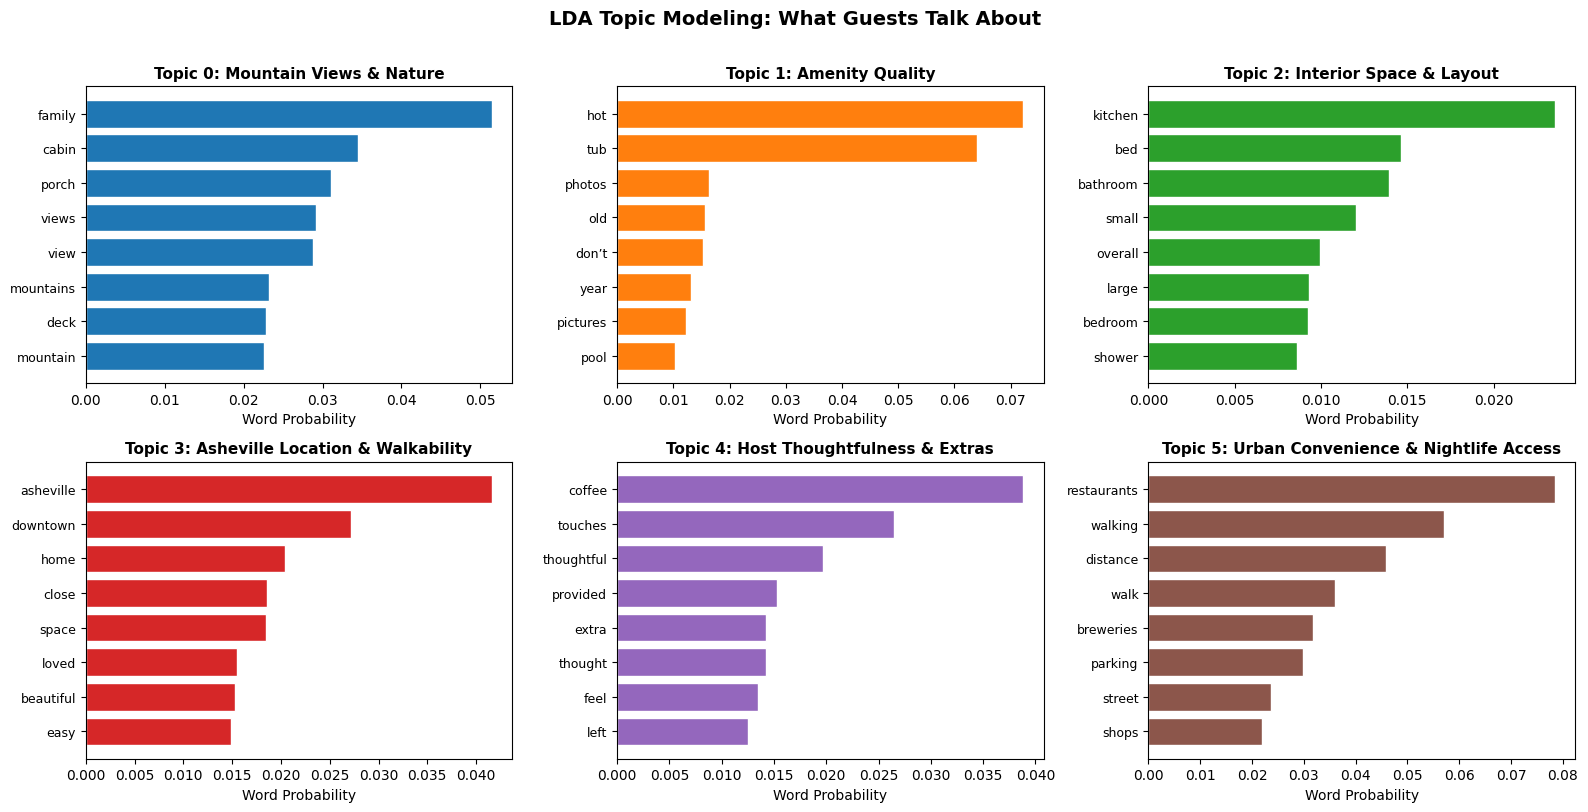

In [56]:

# ── 2f. Visualize: top-words bar chart per topic ─────────────────────────────
n_cols = 3
n_rows = int(np.ceil(N_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = sns.color_palette("tab10", N_TOPICS)

for topic_id in range(N_TOPICS):
    words, weights = zip(*lda_model.show_topic(topic_id, topn=8))
    ax = axes[topic_id]
    ax.barh(list(words)[::-1], list(weights)[::-1],
            color=palette[topic_id], edgecolor="white")
    label = topic_labels.get(topic_id, f"Topic {topic_id}")
    ax.set_title(f"Topic {topic_id}: {label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Word Probability")
    ax.tick_params(axis="y", labelsize=9)

for ax in axes[N_TOPICS:]:
    ax.set_visible(False)

plt.suptitle("LDA Topic Modeling: What Guests Talk About", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("lda_topics.png", dpi=150, bbox_inches="tight")
plt.show()



In [57]:
# -- 2g. Assign dominant topic to each review --------------------------------
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[0]

# Recompute bow per row directly from sample so the index stays aligned.
# (processed_docs dropped short docs, making it shorter than sample.)
sample = sample.copy()
sample["bow"] = sample["comments"].apply(
    lambda text: dictionary.doc2bow(preprocess_review(text))
)
sample["dominant_topic"] = sample["bow"].apply(get_dominant_topic)
sample["topic_label"] = sample["dominant_topic"].map(topic_labels)


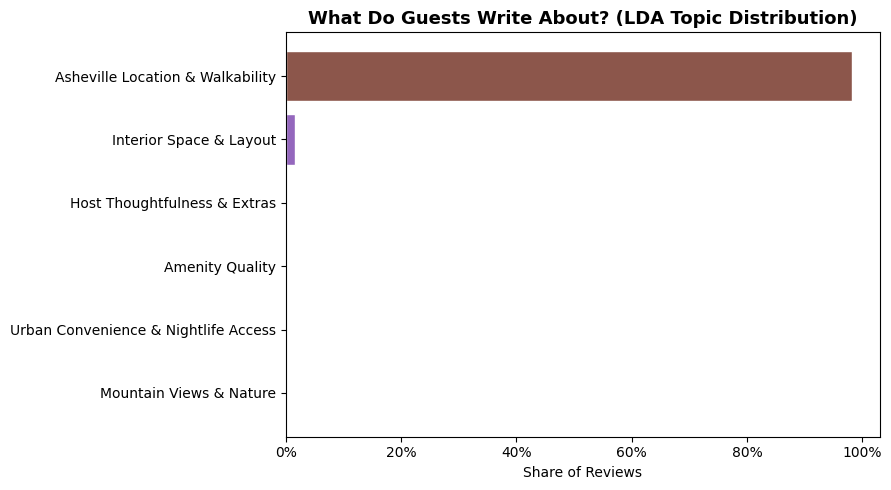

In [58]:
# -- 2h. Topic distribution overall ------------------------------------------
topic_dist = (
    sample["topic_label"]
    .value_counts(normalize=True)
    .reset_index()
    .rename(columns={"proportion": "share"})
    .sort_values("share", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(topic_dist["topic_label"], topic_dist["share"],
        color=palette[:len(topic_dist)], edgecolor="white")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("What Do Guests Write About? (LDA Topic Distribution)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Share of Reviews")
plt.tight_layout()
plt.savefig("lda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


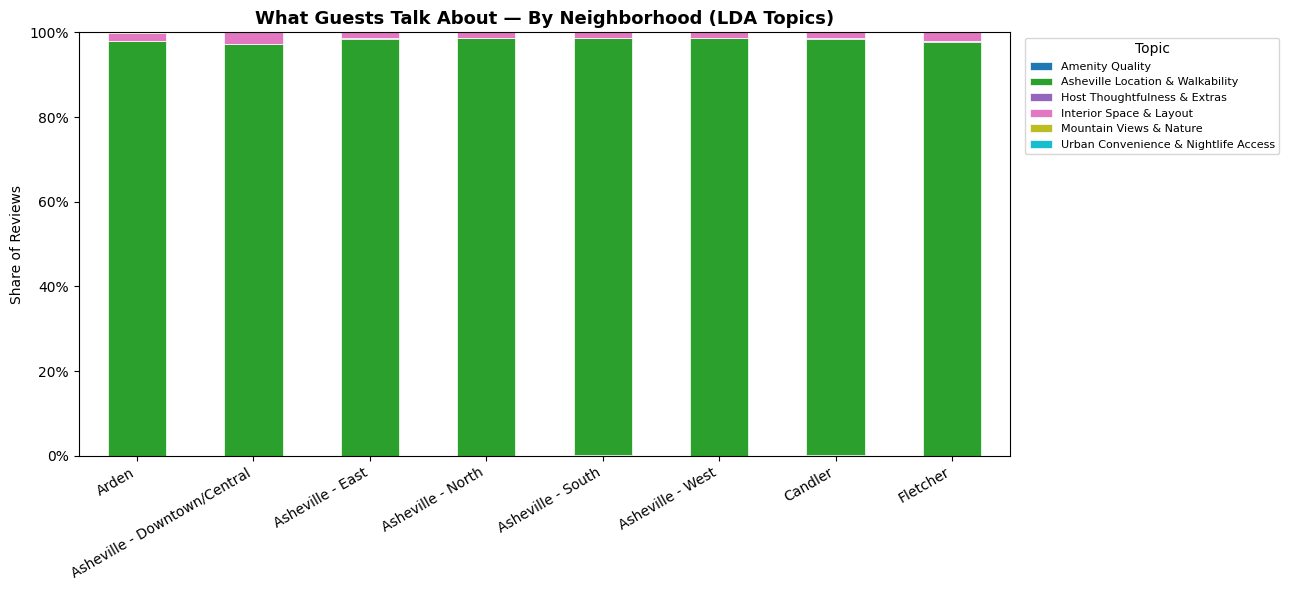

In [59]:

# ── 2i. Topic mix by neighborhood ────────────────────────────────────────────
# Merge neighborhood info back in
sample_geo = sample.merge(
    listing_neighborhood[["id", "neighborhood_name"]],
    left_on="listing_id", right_on="id", how="left"
)

topic_by_neighborhood = (
    sample_geo
    .groupby(["neighborhood_name", "topic_label"])
    .size()
    .reset_index(name="count")
)
topic_pivot = (
    topic_by_neighborhood
    .pivot(index="neighborhood_name", columns="topic_label", values="count")
    .fillna(0)
)
# Normalize to row percentages
topic_pivot_pct = topic_pivot.div(topic_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
topic_pivot_pct.plot(
    kind="bar", stacked=True, ax=ax,
    colormap="tab10", edgecolor="white", linewidth=0.5
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("What Guests Talk About — By Neighborhood (LDA Topics)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Share of Reviews")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("lda_by_neighborhood.png", dpi=150, bbox_inches="tight")
plt.show()



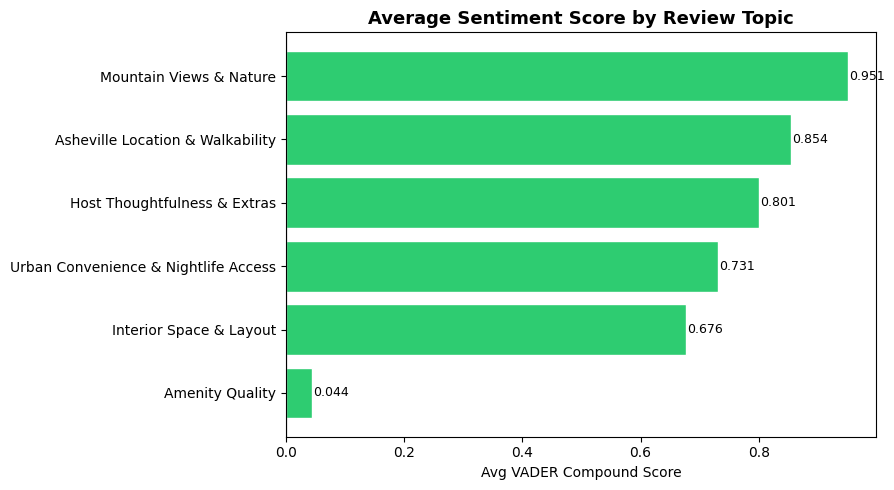

In [60]:
# -- 2j. Sentiment x Topic ---------------------------------------------------
# sample already contains vader_compound (it was drawn from reviews_clean)
sentiment_by_topic = (
    sample
    .groupby("topic_label")["vader_compound"]
    .mean()
    .reset_index()
    .sort_values("vader_compound", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors_st = ["#2ecc71" if v >= 0 else "#e74c3c" for v in sentiment_by_topic["vader_compound"]]
ax.barh(sentiment_by_topic["topic_label"], sentiment_by_topic["vader_compound"],
        color=colors_st, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Sentiment Score by Review Topic",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Avg VADER Compound Score")
for i, (_, row) in enumerate(sentiment_by_topic.iterrows()):
    ax.text(row["vader_compound"] + 0.002, i,
            f"{row['vader_compound']:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("sentiment_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3 Summary

In [61]:

# =============================================================================
# SECTION 3 — SUMMARY TABLE (for slides / Word doc)
# =============================================================================

summary_table = neighborhood_sentiment[[
    "neighborhood_name", "avg_sentiment", "pct_positive", "pct_negative", "review_count"
]].copy()
summary_table.columns = ["Neighborhood", "Avg Sentiment", "% Positive", "% Negative", "# Reviews"]
summary_table["% Positive"] = summary_table["% Positive"].map("{:.1%}".format)
summary_table["% Negative"] = summary_table["% Negative"].map("{:.1%}".format)
summary_table["Avg Sentiment"] = summary_table["Avg Sentiment"].map("{:.3f}".format)
summary_table["# Reviews"]    = summary_table["# Reviews"].map("{:,}".format)

print("\n=== Neighborhood Sentiment Summary ===")
print(summary_table.to_string(index=False))



=== Neighborhood Sentiment Summary ===
                Neighborhood Avg Sentiment % Positive % Negative # Reviews
            Asheville - East         0.865      98.6%       0.5%   124,110
           Asheville - North         0.860      98.3%       0.6%   187,559
            Asheville - West         0.853      98.1%       0.6%   345,599
                       Arden         0.852      97.9%       0.7%    57,870
           Asheville - South         0.849      98.0%       0.7%   191,442
                     Candler         0.846      97.8%       0.9%    32,952
Asheville - Downtown/Central         0.843      97.9%       0.8%   305,795
                    Fletcher         0.838      97.6%       0.7%    25,338
